In [1]:
%pip install numpy pandas scikit-learn torch matplotlib tqdm opencv-python

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.1.1
[notice] To update, run: C:\Users\shiza\OneDrive\Desktop\ИТМО\МАГА\УПРАВЛЕНИЕ ЗНАНИЯМИ\Lab-1\.venv\Scripts\python.exe -m pip install --upgrade pip


In [2]:
import os
import shutil
import tempfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# ── Конфигурация ─────────────────────────────────────────────────
DATA_ROOT   = Path("data-videos/VIPL/VIPL")
SOURCE      = "source1"
WINDOW_SEC  = 10       # длина окна в секундах
STEP_SEC    = 5        # шаг окна
FIXED_LEN   = 256      # длина сигнала после ресемплинга
BATCH_SIZE  = 32
EPOCHS      = 40
LR          = 1e-3
DEVICE      = "cuda" if torch.cuda.is_available() else "cpu"
SEED        = 42
CACHE_DIR   = Path("rppg_cache")
CACHE_DIR.mkdir(exist_ok=True)

torch.manual_seed(SEED)
np.random.seed(SEED)

print(f"Device: {DEVICE}")
print(f"OpenCV: {cv2.__version__}")
print(f"DATA_ROOT exists: {DATA_ROOT.exists()}")
print(f"Cache dir: {CACHE_DIR.resolve()}")


Device: cpu
OpenCV: 4.13.0
DATA_ROOT exists: True
Cache dir: C:\Users\shiza\Knowledge-management\ЛР 1\rppg_cache


# Детекция лица

In [4]:
src_cascade = Path(cv2.data.haarcascades) / "haarcascade_frontalface_default.xml"

if not src_cascade.exists():
    raise FileNotFoundError(f"Не найден файл Haar Cascade: {src_cascade}")

if os.name == "nt":
    safe_dir = Path(r"C:\temp")
else:
    safe_dir = Path(tempfile.gettempdir())

safe_dir.mkdir(parents=True, exist_ok=True)
safe_cascade = safe_dir / "haarcascade_frontalface_default.xml"
shutil.copyfile(src_cascade, safe_cascade)

face_cascade = cv2.CascadeClassifier(str(safe_cascade))

print("Original cascade path:", src_cascade)
print("Safe cascade path:", safe_cascade)
print("Cascade loaded:", not face_cascade.empty())

if face_cascade.empty():
    raise RuntimeError("Не удалось загрузить Haar Cascade для детекции лица")


def detect_face(frame_bgr):
    """
    Возвращает координаты самого большого найденного лица: (x, y, w, h).
    Если лицо не найдено, возвращает None.
    """
    if frame_bgr is None:
        return None

    gray = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2GRAY)

    faces = face_cascade.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=5,
        minSize=(60, 60)
    )

    if len(faces) == 0:
        return None

    return max(faces, key=lambda f: f[2] * f[3])


def get_rois(frame_bgr, face_box):
    """
    Из bounding box лица вырезает три ROI:
      - forehead: верхняя центральная область лица;
      - left_cheek: левая щека;
      - right_cheek: правая щека.

    Возвращает dict {name: mean_rgb_array (3,)}.
    """
    x, y, w, h = [int(v) for v in face_box]
    img_h, img_w = frame_bgr.shape[:2]

    # Ограничиваем координаты рамкой изображения
    x = max(0, x)
    y = max(0, y)
    w = min(w, img_w - x)
    h = min(h, img_h - y)

    rois = {}

    # Лоб: верхние 25% по высоте, центральные 60% по ширине
    fh = int(h * 0.25)
    fw_start = x + int(w * 0.20)
    fw_end = x + int(w * 0.80)
    forehead = frame_bgr[y:y + fh, fw_start:fw_end]

    # Щёки: нижняя часть лица, боковые зоны
    cheek_y = y + int(h * 0.45)
    cheek_h = int(h * 0.35)
    cheek_w = int(w * 0.25)

    left_cheek = frame_bgr[cheek_y:cheek_y + cheek_h, x:x + cheek_w]
    right_cheek = frame_bgr[cheek_y:cheek_y + cheek_h, x + w - cheek_w:x + w]

    for name, roi in [
        ("forehead", forehead),
        ("left_cheek", left_cheek),
        ("right_cheek", right_cheek)
    ]:
        if roi.size == 0:
            rois[name] = np.zeros(3, dtype=np.float32)
        else:
            rgb = cv2.cvtColor(roi, cv2.COLOR_BGR2RGB).astype(np.float32)
            rois[name] = rgb.mean(axis=(0, 1))

    return rois


Original cascade path: C:\Users\shiza\OneDrive\Desktop\ИТМО\МАГА\УПРАВЛЕНИЕ ЗНАНИЯМИ\Lab-1\.venv\Lib\site-packages\cv2\data\haarcascade_frontalface_default.xml
Safe cascade path: C:\temp\haarcascade_frontalface_default.xml
Cascade loaded: True


# Извлечение сигнала

In [5]:
def pos_algorithm(rgb_traces: np.ndarray, fps: float, window_sec: float = 1.6) -> np.ndarray:
    """
    POS алгоритм.
    
    Параметры:
        rgb_traces : (N, 3) — средние RGB значения по кадрам
        fps        : частота кадров видео
        window_sec : длина скользящего окна POS (секунды)
    
    Возвращает:
        rppg : (N,) — нормализованный rPPG сигнал
    """
    N = len(rgb_traces)
    win = max(2, int(window_sec * fps))
    H = np.zeros(N, dtype=np.float64)

    # Проекционная матрица POS
    # S1 = G - R,  S2 = G + R - 2B
    pos_proj = np.array([[0, 1, -1],
                         [-2, 1,  1]], dtype=np.float64)

    for t in range(win, N):
        C = rgb_traces[t - win : t].T.astype(np.float64)  # (3, win)

        # Нормализация: делим каждый канал на его среднее
        mean_c = C.mean(axis=1, keepdims=True)
        mean_c[mean_c == 0] = 1e-6
        Cn = C / mean_c

        # Проекция на плоскость
        S = pos_proj @ Cn  # (2, win)

        # Взвешенная комбинация
        std1 = S[0].std() + 1e-8
        std2 = S[1].std() + 1e-8
        alpha = std1 / std2
        h = S[0] + alpha * S[1]  # (win,)

        # Накапливаем в выходной массив
        H[t - win : t] += h - h.mean()

    # Финальная нормализация
    std_H = H.std()
    if std_H < 1e-8:
        return H
    return (H - H.mean()) / std_H

# Извлечение rPPG из видео

In [6]:
def extract_rppg_from_video(video_path: Path, cache_path: Path):
    """
    Читает видео, извлекает rPPG-сигнал через POS.
    Результат кэшируется в .npz файл.
    Возвращает dict: {roi_name: rppg_signal, 'fps': fps}.
    """
    if cache_path.exists():
        try:
            data = np.load(cache_path)
            return {k: data[k] for k in data.files}
        except Exception:
            # Если кэш повреждён, удаляем и пересчитываем
            cache_path.unlink(missing_ok=True)

    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        print(f"Не удалось открыть видео: {video_path}")
        return None

    fps = cap.get(cv2.CAP_PROP_FPS)
    if fps <= 0:
        fps = 25.0

    traces = {"forehead": [], "left_cheek": [], "right_cheek": []}
    last_face = None
    frame_idx = 0
    detected_faces = 0

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        # Детектируем лицо каждые 15 кадров для ускорения
        if frame_idx % 15 == 0:
            face = detect_face(frame)
            if face is not None:
                last_face = face
                detected_faces += 1

        if last_face is not None:
            rois = get_rois(frame, last_face)
            for roi_name in traces:
                traces[roi_name].append(rois[roi_name])
        else:
            for roi_name in traces:
                traces[roi_name].append(np.zeros(3, dtype=np.float32))

        frame_idx += 1

    cap.release()

    if frame_idx == 0:
        return None

    # Если лицо ни разу не найдено, такую запись лучше пропустить
    if detected_faces == 0:
        return None

    result = {"fps": np.array([fps], dtype=np.float32)}

    for roi_name, trace in traces.items():
        rgb_arr = np.array(trace, dtype=np.float32)
        rppg = pos_algorithm(rgb_arr, fps).astype(np.float32)
        result[roi_name] = rppg

    np.savez_compressed(cache_path, **result)
    return result


# Загрузка сессий

In [8]:
def collect_sessions_with_rppg(data_root: Path, source: str, cache_dir: Path):
    sessions = []
    errors = []

    if not data_root.exists():
        raise FileNotFoundError(
            f"Папка с датасетом не найдена: {data_root}. "
            "Проверь переменную DATA_ROOT."
        )

    paths = []
    for group_dir in sorted(data_root.iterdir()):
        if not group_dir.is_dir():
            continue
        for p_dir in sorted(group_dir.iterdir()):
            if not p_dir.is_dir():
                continue
            for v_dir in sorted(p_dir.iterdir()):
                if not v_dir.is_dir():
                    continue
                src_path = v_dir / source
                if not src_path.is_dir():
                    continue
                paths.append({
                    "src_path": src_path,
                    "group": group_dir.name,
                    "subject": p_dir.name,
                    "session": v_dir.name,
                })

    print(f"Найдено путей для {source}: {len(paths)}")

    for info in tqdm(paths, desc="Обработка видео"):
        src = info["src_path"]
        video_path = src / "video.avi"
        hr_path = src / "gt_HR.csv"
        time_path = src / "time.txt"

        if not (video_path.exists() and hr_path.exists() and time_path.exists()):
            errors.append({**info, "error": "missing video/hr/time file"})
            continue

        cache_key = f"{info['group']}_{info['subject']}_{info['session']}_{source}"
        cache_file = cache_dir / f"{cache_key}.npz"

        try:
            rppg_data = extract_rppg_from_video(video_path, cache_file)
            if rppg_data is None:
                errors.append({**info, "error": "rPPG extraction failed or face not detected"})
                continue

            hr = pd.read_csv(hr_path)["HR"].values.astype(np.float32)
            time = np.loadtxt(time_path, dtype=int)

            sessions.append({
                **info,
                "rppg": rppg_data,
                "hr": hr,
                "time": time,
                "fps": float(rppg_data["fps"][0]),
            })
        except Exception as e:
            errors.append({**info, "error": str(e)})
            continue

    return sessions, pd.DataFrame(errors)


print("Начинаем извлечение rPPG из видео...")
print("Первый запуск может быть долгим — кэш сохраняется в папку rppg_cache/.")

all_sessions, errors_df = collect_sessions_with_rppg(DATA_ROOT, SOURCE, CACHE_DIR)

print(f"\nУспешно обработано сессий: {len(all_sessions)}")
print(f"Ошибок/пропущенных записей: {len(errors_df)}")

if len(errors_df) > 0:
    errors_df.head()

if all_sessions:
    s = all_sessions[0]
    print(f"Пример: {s['group']}/{s['subject']}/{s['session']}, fps={s['fps']}")
    for roi in ["forehead", "left_cheek", "right_cheek"]:
        print(f"  {roi}: {s['rppg'][roi].shape}")
    print(f"  HR: {s['hr'].shape}, time: {s['time'].shape}")
else:
    raise RuntimeError("Не удалось обработать ни одной сессии. Проверить DATA_ROOT, SOURCE и качество детекции лица.")


Начинаем извлечение rPPG из видео...
Первый запуск может быть долгим — кэш сохраняется в папку rppg_cache/.
Найдено путей для source1: 203


Обработка видео: 100%|██████████| 203/203 [04:09<00:00,  1.23s/it]


Успешно обработано сессий: 198
Ошибок/пропущенных записей: 5
Пример: p1-5/p1/v1, fps=25.0
  forehead: (1036,)
  left_cheek: (1036,)
  right_cheek: (1036,)
  HR: (36,), time: (1036,)


# Визуализация

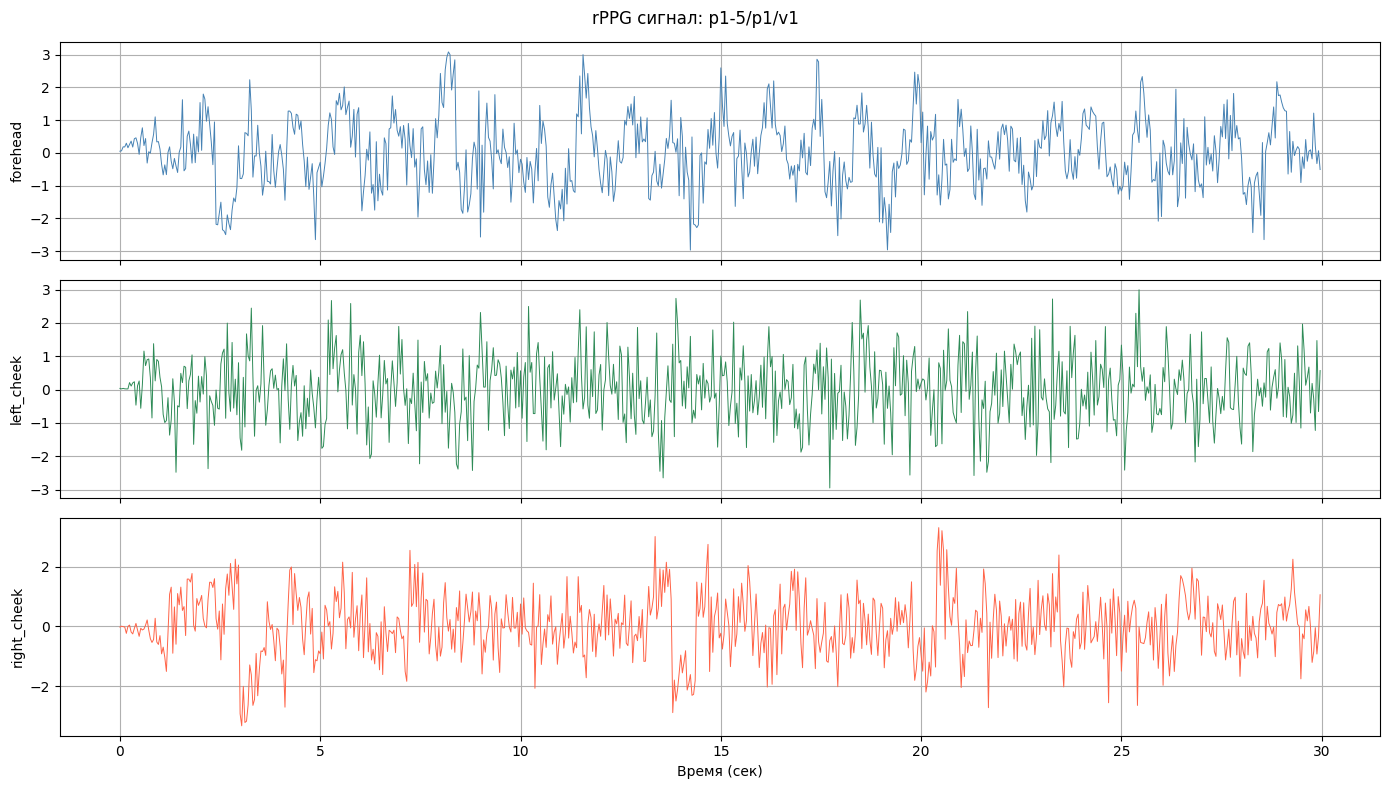

In [9]:
if not all_sessions:
    raise RuntimeError("Нет обработанных сессий для визуализации")

s = all_sessions[0]
fps = s["fps"]
n_frames = len(s["rppg"]["right_cheek"])
t_axis = np.arange(n_frames) / fps

fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
colors = ["steelblue", "seagreen", "tomato"]

for ax, roi, color in zip(axes, ["forehead", "left_cheek", "right_cheek"], colors):
    sig = s["rppg"][roi]
    n_show = min(len(sig), int(fps * 30))
    ax.plot(t_axis[:n_show], sig[:n_show], color=color, lw=0.7)
    ax.set_ylabel(roi)
    ax.grid(True)

axes[-1].set_xlabel("Время (сек)")
fig.suptitle(f"rPPG сигнал: {s['group']}/{s['subject']}/{s['session']}")
plt.tight_layout()
plt.show()


# Нарезка на окна

In [10]:
def resample_signal(sig, n):
    if len(sig) < 2:
        return np.zeros(n, dtype=np.float32)
    return np.interp(
        np.linspace(0, 1, n),
        np.linspace(0, 1, len(sig)),
        sig
    ).astype(np.float32)


def make_windows_rppg(sess, win_sec, step_sec, fixed_len, roi="right_cheek"):
    """
    Нарезает rPPG-сигнал на окна, синхронизированные с gt_HR.
    Использует time.txt для выравнивания кадров и секунд.
    """
    rppg = sess["rppg"][roi]
    hr = sess["hr"]
    time = sess["time"]

    n = min(len(hr), len(time))
    wins = []

    if n < win_sec:
        return wins

    for start in range(0, n - win_sec + 1, step_sec):
        end = start + win_sec
        fs = int(time[start])
        fe = int(time[end - 1])

        if fs < 0 or fe <= fs or fe > len(rppg):
            continue

        seg = resample_signal(rppg[fs:fe], fixed_len)
        std = seg.std()
        if std < 1e-6:
            continue

        seg = (seg - seg.mean()) / std
        target = float(hr[start:end].mean())
        wins.append((seg, target))

    return wins


all_X, all_y = [], []

for sess in tqdm(all_sessions, desc="Нарезка окон"):
    for x, y in make_windows_rppg(sess, WINDOW_SEC, STEP_SEC, FIXED_LEN, roi="right_cheek"):
        all_X.append(x)
        all_y.append(y)

all_X = np.array(all_X, dtype=np.float32)
all_y = np.array(all_y, dtype=np.float32)

if len(all_X) == 0:
    raise RuntimeError("Не получилось сформировать окна. Проверить WINDOW_SEC, STEP_SEC, time.txt и rPPG-сигналы.")

print(f"Окон: {len(all_X)}, X shape: {all_X.shape}")
print(f"HR range: {all_y.min():.1f}–{all_y.max():.1f}, mean: {all_y.mean():.1f} BPM")

np.savez_compressed("rppg_windows_dataset.npz", X=all_X, y=all_y)
print("Окна сохранены в rppg_windows_dataset.npz")


Нарезка окон: 100%|██████████| 198/198 [00:00<00:00, 6424.22it/s]

Окон: 329, X shape: (329, 256)
HR range: 57.2–143.9, mean: 81.4 BPM
Окна сохранены в rppg_windows_dataset.npz


# Обучение

In [11]:
if len(all_X) < 10:
    raise RuntimeError("Слишком мало окон для train/val/test split")

X_tr, X_tmp, y_tr, y_tmp = train_test_split(
    all_X,
    all_y,
    test_size=0.3,
    random_state=SEED,
    shuffle=True
)

X_val, X_te, y_val, y_te = train_test_split(
    X_tmp,
    y_tmp,
    test_size=0.5,
    random_state=SEED,
    shuffle=True
)

print(f"Train: {len(X_tr):,} | Val: {len(X_val):,} | Test: {len(X_te):,}")


Train: 230 | Val: 49 | Test: 50


In [12]:
class HRDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X[:, np.newaxis, :], dtype=torch.float32)  # (N, 1, L)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, i):
        return self.X[i], self.y[i]


train_dl = DataLoader(HRDataset(X_tr, y_tr), batch_size=BATCH_SIZE, shuffle=True)
val_dl = DataLoader(HRDataset(X_val, y_val), batch_size=BATCH_SIZE, shuffle=False)
test_dl = DataLoader(HRDataset(X_te, y_te), batch_size=BATCH_SIZE, shuffle=False)

In [13]:
class CNN_LSTM(nn.Module):
    """
    1D CNN → LSTM → FC регрессор
    Вход:  (batch, 1, L)
    Выход: (batch,)  — HR в BPM
    """
    def __init__(self, seq_len=256, lstm_hidden=128, lstm_layers=2):
        super().__init__()

        # CNN часть — извлекаем признаки из сигнала
        self.cnn = nn.Sequential(
            nn.Conv1d(1,  32, kernel_size=7, padding=3), nn.BatchNorm1d(32),  nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(32, 64, kernel_size=5, padding=2), nn.BatchNorm1d(64),  nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(64, 64, kernel_size=3, padding=1), nn.BatchNorm1d(64),  nn.ReLU(),
        )
        # После CNN: (batch, 64, seq_len//4)
        cnn_out_len = seq_len // 4

        # LSTM часть — (batch, seq, features)
        self.lstm = nn.LSTM(
            input_size=64,
            hidden_size=lstm_hidden,
            num_layers=lstm_layers,
            batch_first=True,
            dropout=0.3 if lstm_layers > 1 else 0.0,
        )

        # FC регрессор
        self.fc = nn.Sequential(
            nn.Linear(lstm_hidden, 64), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        # x: (batch, 1, L)
        features = self.cnn(x)              # (batch, 64, L//4)
        features = features.permute(0,2,1)  # (batch, L//4, 64) — для LSTM
        out, _   = self.lstm(features)      # (batch, L//4, hidden)
        last     = out[:, -1, :]            # берём последний timestep
        return self.fc(last).squeeze(1)     # (batch,)


model = CNN_LSTM(seq_len=FIXED_LEN).to(DEVICE)
total = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Параметров: {total:,}")
print(model)

Параметров: 262,977
CNN_LSTM(
  (cnn): Sequential(
    (0): Conv1d(1, 32, kernel_size=(7,), stride=(1,), padding=(3,))
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=(2,))
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
  )
  (lstm): LSTM(64, 128, num_layers=2, batch_first=True, dropout=0.3)
  (fc): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(i

In [14]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

history = {"train_loss": [], "val_loss": [], "val_mae": []}
best_val_mae = float("inf")


def run_epoch(dl, train=True):
    model.train() if train else model.eval()
    total_loss = 0.0
    preds, tgts = [], []

    context = torch.enable_grad() if train else torch.no_grad()
    with context:
        for X_b, y_b in dl:
            X_b = X_b.to(DEVICE)
            y_b = y_b.to(DEVICE)

            out = model(X_b)
            loss = criterion(out, y_b)

            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * len(y_b)
            preds.extend(out.detach().cpu().numpy())
            tgts.extend(y_b.detach().cpu().numpy())

    avg_loss = total_loss / len(dl.dataset)
    mae_value = mean_absolute_error(tgts, preds)
    return avg_loss, mae_value


for ep in range(1, EPOCHS + 1):
    tr_l, tr_m = run_epoch(train_dl, train=True)
    vl_l, vl_m = run_epoch(val_dl, train=False)

    scheduler.step(vl_l)

    history["train_loss"].append(tr_l)
    history["val_loss"].append(vl_l)
    history["val_mae"].append(vl_m)

    if vl_m < best_val_mae:
        best_val_mae = vl_m
        torch.save(model.state_dict(), "best_model_complex.pth")

    if ep % 5 == 0 or ep == 1:
        print(f"Ep {ep:3d}/{EPOCHS} | Train {tr_l:.3f}/{tr_m:.2f} | Val {vl_l:.3f}/{vl_m:.2f} BPM")

print(f"\nЛучший Val MAE: {best_val_mae:.2f} BPM")


Ep   1/40 | Train 6722.122/80.55 | Val 7362.365/83.87 BPM
Ep   5/40 | Train 5066.421/69.44 | Val 5269.253/70.29 BPM
Ep  10/40 | Train 1936.156/40.74 | Val 1945.082/40.21 BPM
Ep  15/40 | Train 488.168/16.52 | Val 442.298/15.30 BPM
Ep  20/40 | Train 372.336/15.26 | Val 351.927/14.06 BPM
Ep  25/40 | Train 352.266/14.44 | Val 344.114/14.06 BPM
Ep  30/40 | Train 329.692/13.96 | Val 342.107/14.07 BPM
Ep  35/40 | Train 316.438/13.43 | Val 352.068/14.06 BPM
Ep  40/40 | Train 358.004/14.41 | Val 352.611/14.06 BPM

Лучший Val MAE: 14.05 BPM


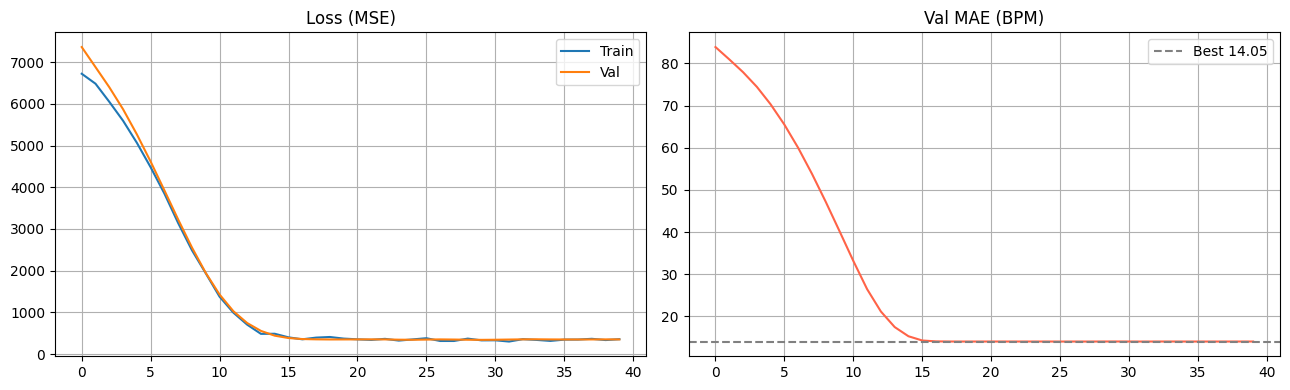

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(history["train_loss"], label="Train")
ax[0].plot(history["val_loss"],   label="Val")
ax[0].set_title("Loss (MSE)"); ax[0].legend(); ax[0].grid(True)
ax[1].plot(history["val_mae"], color="tomato")
ax[1].axhline(best_val_mae, ls="--", color="gray", label=f"Best {best_val_mae:.2f}")
ax[1].set_title("Val MAE (BPM)"); ax[1].legend(); ax[1].grid(True)
plt.tight_layout(); plt.show()

Test MAE:  12.09 BPM
Test RMSE: 15.68 BPM


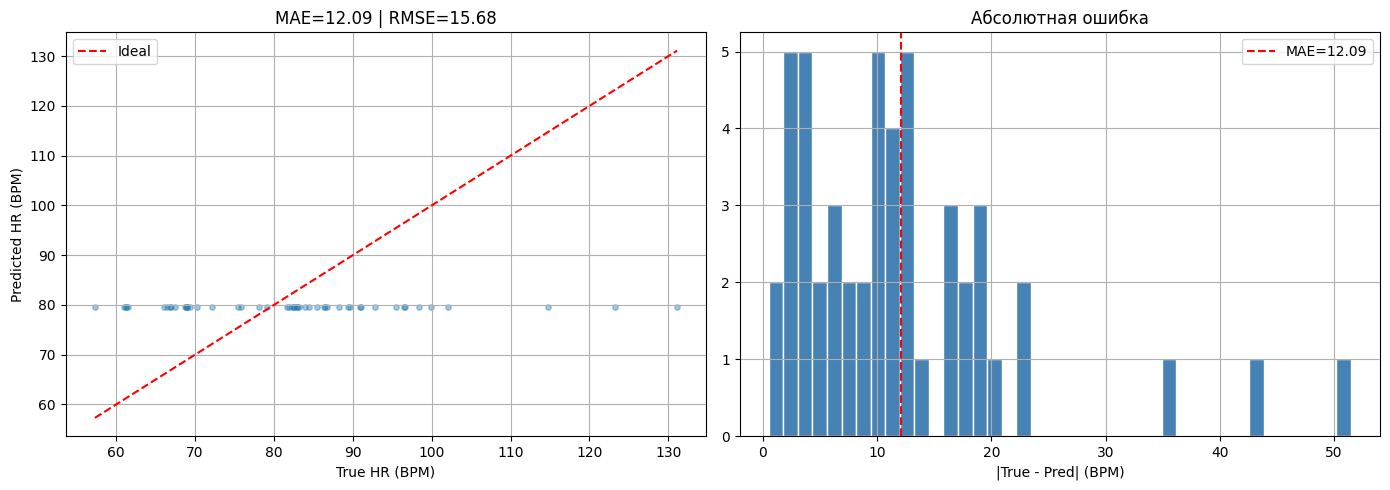

< 5 BPM:  28.0%
< 10 BPM: 46.0%


In [16]:
model_path = Path("best_model_complex.pth")
if not model_path.exists():
    raise FileNotFoundError("Файл best_model_complex.pth не найден. Сначала запусти обучение модели.")

state = torch.load(model_path, map_location=DEVICE)
model.load_state_dict(state)
model.eval()

preds, tgts = [], []

with torch.no_grad():
    for X_b, y_b in test_dl:
        preds.extend(model(X_b.to(DEVICE)).cpu().numpy())
        tgts.extend(y_b.numpy())

preds = np.array(preds)
tgts = np.array(tgts)

test_mae = mean_absolute_error(tgts, preds)
test_rmse = np.sqrt(mean_squared_error(tgts, preds))

print(f"Test MAE:  {test_mae:.2f} BPM")
print(f"Test RMSE: {test_rmse:.2f} BPM")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(tgts, preds, alpha=0.4, s=15)
mn, mx = min(tgts.min(), preds.min()), max(tgts.max(), preds.max())
axes[0].plot([mn, mx], [mn, mx], "r--", label="Ideal")
axes[0].set_xlabel("True HR (BPM)")
axes[0].set_ylabel("Predicted HR (BPM)")
axes[0].set_title(f"MAE={test_mae:.2f} | RMSE={test_rmse:.2f}")
axes[0].legend()
axes[0].grid(True)

err = np.abs(tgts - preds)
axes[1].hist(err, bins=40, color="steelblue", edgecolor="white")
axes[1].axvline(test_mae, color="red", ls="--", label=f"MAE={test_mae:.2f}")
axes[1].set_title("Абсолютная ошибка")
axes[1].set_xlabel("|True - Pred| (BPM)")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

print(f"< 5 BPM:  {(err < 5).mean() * 100:.1f}%")
print(f"< 10 BPM: {(err < 10).mean() * 100:.1f}%")


# Сравнение

In [17]:
simple_mae = 11.38
simple_rmse = 15.01

results_df = pd.DataFrame({
    "Model": ["Simple Random Forest", "rPPG + CNN + LSTM"],
    "MAE": [simple_mae, test_mae],
    "RMSE": [simple_rmse, test_rmse],
})

results_df

print("=" * 45)
print(f"{'Модель':<25} {'MAE':>8} {'RMSE':>8}")
print("-" * 45)
print(f"{'Simple RF':<25} {simple_mae:>8.2f} {simple_rmse:>8.2f}")
print(f"{'rPPG+CNN+LSTM':<25} {test_mae:>8.2f} {test_rmse:>8.2f}")
print("=" * 45)


Модель                         MAE     RMSE
---------------------------------------------
Simple RF                    11.38    15.01
rPPG+CNN+LSTM                12.09    15.68


# Улучшение моделей

DATA_ROOT exists: True
SOURCE: source1
CACHE_DIR: rppg_cache_improved
Cascade path: C:\temp\haarcascade_frontalface_default.xml
Cascade loaded: True
Найдено видео: 203
{'group': 'p1-5', 'person': 'p1', 'session': 'v1', 'source': 'source1', 'src_dir': WindowsPath('data-videos/VIPL/VIPL/p1-5/p1/v1/source1'), 'video_path': WindowsPath('data-videos/VIPL/VIPL/p1-5/p1/v1/source1/video.avi'), 'hr_path': WindowsPath('data-videos/VIPL/VIPL/p1-5/p1/v1/source1/gt_HR.csv'), 'time_path': WindowsPath('data-videos/VIPL/VIPL/p1-5/p1/v1/source1/time.txt'), 'session_id': 'p1-5_p1_v1_source1'}


Извлечение rPPG: 100%|██████████| 203/203 [06:07<00:00,  1.81s/it]

Успешно обработано сессий: 203


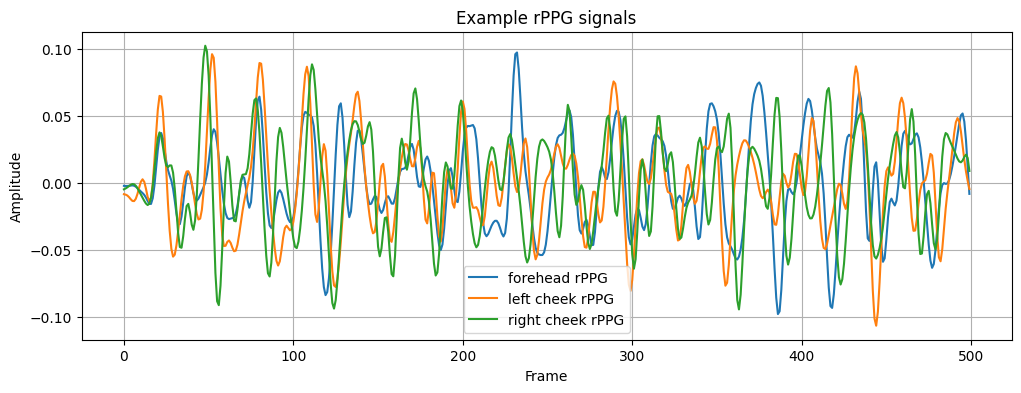

Формирование окон: 100%|██████████| 203/203 [00:24<00:00,  8.45it/s]


Dataset shape: (3326, 97)
Dataset shape after cleaning: (3326, 97)
Сохранено: hr_rppg_window_features_improved.csv


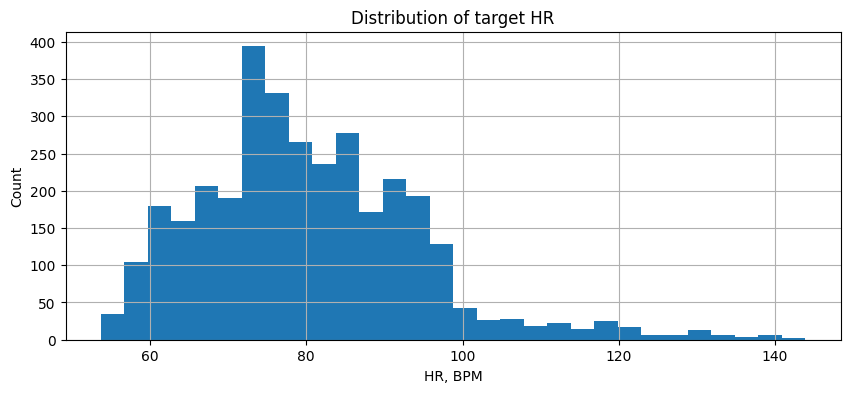

Train size: (2687, 90)
Test size: (639, 90)
Train sessions: 162
Test sessions: 41
Сохранено: improved_model_results.csv
Best model: Baseline mean


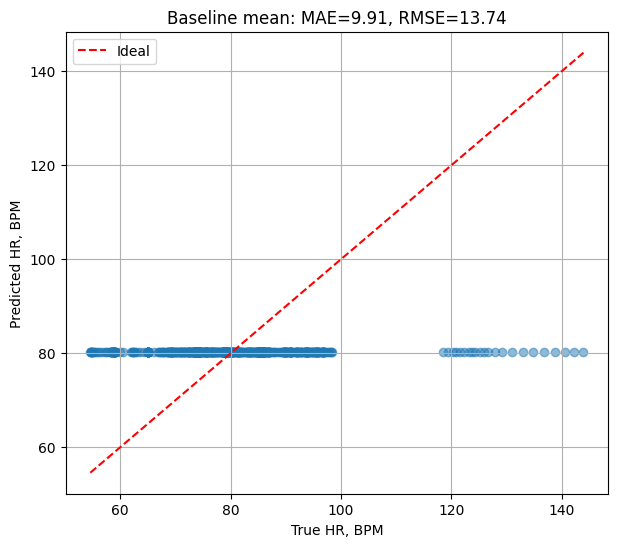

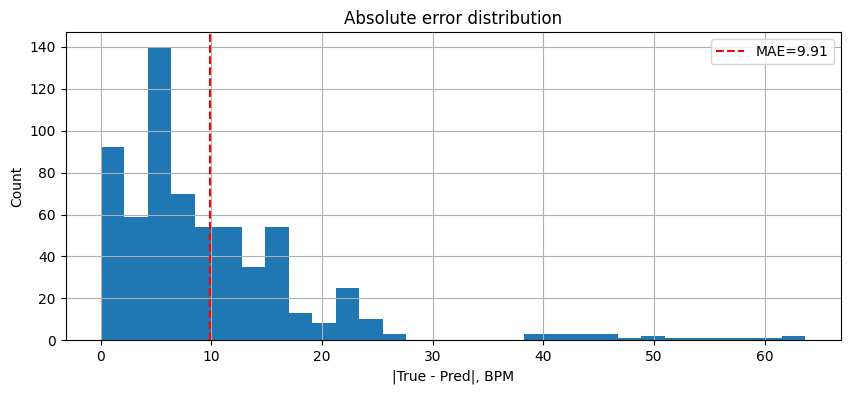

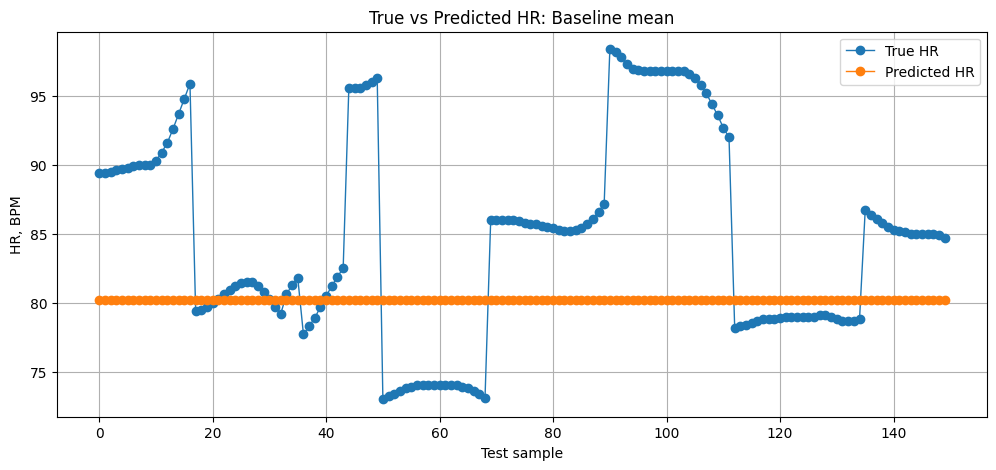

In [18]:
from pathlib import Path
import shutil
import warnings

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm import tqdm
from scipy.signal import butter, filtfilt, welch
from scipy.stats import skew, kurtosis

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import ExtraTreesRegressor, RandomForestRegressor, HistGradientBoostingRegressor

warnings.filterwarnings("ignore")


# =========================
# Настройки
# =========================

DATA_ROOT = Path("data-videos/VIPL/VIPL")
SOURCE = "source1"
CACHE_DIR = Path("rppg_cache_improved")
CACHE_DIR.mkdir(exist_ok=True)

WINDOW_SEC = 10
STEP_SEC = 1

print("DATA_ROOT exists:", DATA_ROOT.exists())
print("SOURCE:", SOURCE)
print("CACHE_DIR:", CACHE_DIR)


# =========================
# загрузка Haar Cascade
# =========================

safe_dir = Path(r"C:\temp")
safe_dir.mkdir(exist_ok=True)

src_cascade = Path(cv2.data.haarcascades) / "haarcascade_frontalface_default.xml"
safe_cascade = safe_dir / "haarcascade_frontalface_default.xml"

if not safe_cascade.exists():
    shutil.copy(src_cascade, safe_cascade)

face_cascade = cv2.CascadeClassifier(str(safe_cascade))

print("Cascade path:", safe_cascade)
print("Cascade loaded:", not face_cascade.empty())

if face_cascade.empty():
    raise RuntimeError("Не удалось загрузить Haar Cascade")


# =========================
# Детекция лица и ROI
# =========================

def fallback_face(frame_bgr):
  
    h, w = frame_bgr.shape[:2]

    box_w = int(w * 0.55)
    box_h = int(h * 0.75)

    x = int((w - box_w) / 2)
    y = int(h * 0.08)

    return (x, y, box_w, box_h)


def detect_face(frame_bgr):
   
    gray = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2GRAY)

    faces = face_cascade.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=5,
        minSize=(80, 80)
    )

    if len(faces) == 0:
        return fallback_face(frame_bgr)

    return max(faces, key=lambda f: f[2] * f[3])


def crop_mean_rgb(frame_bgr, x1, y1, x2, y2):
    """
    Вырезает область и возвращает среднее RGB.
    """
    h, w = frame_bgr.shape[:2]

    x1 = max(0, min(w - 1, x1))
    x2 = max(0, min(w, x2))
    y1 = max(0, min(h - 1, y1))
    y2 = max(0, min(h, y2))

    roi = frame_bgr[y1:y2, x1:x2]

    if roi.size == 0:
        return np.zeros(3, dtype=np.float32)

    roi_rgb = cv2.cvtColor(roi, cv2.COLOR_BGR2RGB).astype(np.float32)
    return roi_rgb.mean(axis=(0, 1))


def get_rois_rgb(frame_bgr, face_box):
    """
    Выделяет 3 области кожи:
    - forehead
    - left_cheek
    - right_cheek

    Возвращает средний RGB для каждой области.
    """
    x, y, w, h = face_box

    rois = {}

    # Лоб: центральная часть, без волос и бровей
    fx1 = x + int(w * 0.30)
    fx2 = x + int(w * 0.70)
    fy1 = y + int(h * 0.16)
    fy2 = y + int(h * 0.30)

    # Левая щека
    lx1 = x + int(w * 0.18)
    lx2 = x + int(w * 0.38)
    ly1 = y + int(h * 0.48)
    ly2 = y + int(h * 0.70)

    # Правая щека
    rx1 = x + int(w * 0.62)
    rx2 = x + int(w * 0.82)
    ry1 = y + int(h * 0.48)
    ry2 = y + int(h * 0.70)

    rois["forehead"] = crop_mean_rgb(frame_bgr, fx1, fy1, fx2, fy2)
    rois["left_cheek"] = crop_mean_rgb(frame_bgr, lx1, ly1, lx2, ly2)
    rois["right_cheek"] = crop_mean_rgb(frame_bgr, rx1, ry1, rx2, ry2)

    return rois


# =========================
# Фильтрация и POS rPPG
# =========================

def bandpass_filter(signal, fs, low=0.7, high=3.0, order=3):
    """
    Фильтр для диапазона пульса примерно 42–180 BPM.
    """
    signal = np.asarray(signal, dtype=np.float32)

    if len(signal) < fs * 3:
        return signal

    nyq = 0.5 * fs
    low = low / nyq
    high = high / nyq

    b, a = butter(order, [low, high], btype="band")

    try:
        return filtfilt(b, a, signal)
    except Exception:
        return signal


def pos_algorithm(rgb_trace, fs, win_sec=1.6):
    """
    POS algorithm для извлечения rPPG из RGB-трассы.
    rgb_trace: array shape (N, 3)
    """
    rgb_trace = np.asarray(rgb_trace, dtype=np.float32)

    n = rgb_trace.shape[0]
    win = int(win_sec * fs)

    if n < win + 2:
        return np.zeros(n, dtype=np.float32)

    h = np.zeros(n, dtype=np.float32)

    for i in range(win, n):
        segment = rgb_trace[i - win:i].T

        mean = np.mean(segment, axis=1, keepdims=True)
        mean[mean == 0] = 1e-6

        normalized = segment / mean

        s1 = normalized[1] - normalized[2]
        s2 = -2 * normalized[0] + normalized[1] + normalized[2]

        alpha = np.std(s1) / (np.std(s2) + 1e-6)
        pos = s1 + alpha * s2
        pos = pos - np.mean(pos)

        h[i - win:i] += pos * np.hanning(win)

    h = bandpass_filter(h, fs)

    return h.astype(np.float32)


# =========================
# Извлечение rPPG из одного видео
# =========================

def extract_rppg_from_video(video_path: Path, cache_path: Path):
    """
    Извлекает RGB-трассы и rPPG-сигналы из видео.
    Результат кэшируется.
    """
    if cache_path.exists():
        data = np.load(cache_path)
        return {k: data[k] for k in data.files}

    cap = cv2.VideoCapture(str(video_path))

    if not cap.isOpened():
        return None

    fps = cap.get(cv2.CAP_PROP_FPS)
    if fps <= 0:
        fps = 25.0

    traces = {
        "forehead_rgb": [],
        "left_cheek_rgb": [],
        "right_cheek_rgb": []
    }

    last_face = None
    frame_idx = 0

    while True:
        ret, frame = cap.read()

        if not ret:
            break

        if frame_idx % 10 == 0:
            last_face = detect_face(frame)

        if last_face is None:
            last_face = fallback_face(frame)

        rois = get_rois_rgb(frame, last_face)

        traces["forehead_rgb"].append(rois["forehead"])
        traces["left_cheek_rgb"].append(rois["left_cheek"])
        traces["right_cheek_rgb"].append(rois["right_cheek"])

        frame_idx += 1

    cap.release()

    if frame_idx == 0:
        return None

    result = {
        "fps": np.array([fps], dtype=np.float32)
    }

    for roi_name in ["forehead", "left_cheek", "right_cheek"]:
        rgb = np.array(traces[f"{roi_name}_rgb"], dtype=np.float32)

        result[f"{roi_name}_rgb"] = rgb
        result[f"{roi_name}_rppg"] = pos_algorithm(rgb, fps).astype(np.float32)

        green = rgb[:, 1]
        result[f"{roi_name}_green"] = bandpass_filter(green, fps).astype(np.float32)

    np.savez_compressed(cache_path, **result)

    return result


# =========================
# Сбор путей по датасету
# =========================

def collect_video_paths(data_root: Path, source: str):
    paths = []

    for group_dir in sorted(data_root.iterdir()):
        if not group_dir.is_dir():
            continue

        for person_dir in sorted(group_dir.iterdir()):
            if not person_dir.is_dir():
                continue

            for session_dir in sorted(person_dir.iterdir()):
                if not session_dir.is_dir():
                    continue

                src_dir = session_dir / source

                if not src_dir.is_dir():
                    continue

                video_path = src_dir / "video.avi"
                hr_path = src_dir / "gt_HR.csv"
                time_path = src_dir / "time.txt"

                if video_path.exists() and hr_path.exists():
                    paths.append({
                        "group": group_dir.name,
                        "person": person_dir.name,
                        "session": session_dir.name,
                        "source": source,
                        "src_dir": src_dir,
                        "video_path": video_path,
                        "hr_path": hr_path,
                        "time_path": time_path if time_path.exists() else None,
                        "session_id": f"{group_dir.name}_{person_dir.name}_{session_dir.name}_{source}"
                    })

    return paths


video_paths = collect_video_paths(DATA_ROOT, SOURCE)

print("Найдено видео:", len(video_paths))
print(video_paths[0] if video_paths else "Нет видео")


# =========================
# Сбор сессий с rPPG
# =========================

def collect_sessions(video_paths, cache_dir: Path, max_sessions=None):
    sessions = []

    selected_paths = video_paths if max_sessions is None else video_paths[:max_sessions]

    for item in tqdm(selected_paths, desc="Извлечение rPPG"):
        cache_file = cache_dir / f"{item['session_id']}.npz"

        rppg_data = extract_rppg_from_video(item["video_path"], cache_file)

        if rppg_data is None:
            continue

        try:
            hr_df = pd.read_csv(item["hr_path"])
            hr = pd.to_numeric(hr_df["HR"], errors="coerce").dropna().values.astype(np.float32)
        except Exception:
            continue

        if len(hr) == 0:
            continue

        sessions.append({
            **item,
            "rppg_data": rppg_data,
            "hr": hr,
            "fps": float(rppg_data["fps"][0])
        })

    return sessions


all_sessions = collect_sessions(video_paths, CACHE_DIR, max_sessions=None)

print("Успешно обработано сессий:", len(all_sessions))


# =========================
# Визуальная проверка одного rPPG-сигнала
# =========================

if len(all_sessions) > 0:
    s = all_sessions[0]
    fps = s["fps"]

    plt.figure(figsize=(12, 4))
    plt.plot(s["rppg_data"]["forehead_rppg"][:int(fps * 20)], label="forehead rPPG")
    plt.plot(s["rppg_data"]["left_cheek_rppg"][:int(fps * 20)], label="left cheek rPPG")
    plt.plot(s["rppg_data"]["right_cheek_rppg"][:int(fps * 20)], label="right cheek rPPG")
    plt.title("Example rPPG signals")
    plt.xlabel("Frame")
    plt.ylabel("Amplitude")
    plt.grid(True)
    plt.legend()
    plt.show()


# =========================
# Извлечение признаков из окна
# =========================

def dominant_hr_from_signal(signal, fs):
    """
    Оценивает доминирующую частоту пульса через спектр.
    Возвращает BPM и силу пика.
    """
    signal = np.asarray(signal, dtype=np.float32)

    if len(signal) < fs * 3:
        return 0.0, 0.0

    signal = signal - np.mean(signal)

    if np.std(signal) < 1e-6:
        return 0.0, 0.0

    freqs, power = welch(signal, fs=fs, nperseg=min(len(signal), int(fs * 8)))

    mask = (freqs >= 0.7) & (freqs <= 3.0)

    if mask.sum() == 0:
        return 0.0, 0.0

    freqs_band = freqs[mask]
    power_band = power[mask]

    peak_idx = np.argmax(power_band)

    peak_freq = freqs_band[peak_idx]
    peak_bpm = peak_freq * 60.0

    peak_power = power_band[peak_idx]
    total_power = np.sum(power_band) + 1e-6

    peak_ratio = peak_power / total_power

    return float(peak_bpm), float(peak_ratio)


def signal_features(signal, fs, prefix):
    """
    Считает признаки из одного сигнала.
    """
    signal = np.asarray(signal, dtype=np.float32)

    if len(signal) == 0:
        return {}

    sig = signal.copy()

    features = {}

    features[f"{prefix}_mean"] = float(np.mean(sig))
    features[f"{prefix}_std"] = float(np.std(sig))
    features[f"{prefix}_min"] = float(np.min(sig))
    features[f"{prefix}_max"] = float(np.max(sig))
    features[f"{prefix}_range"] = float(np.max(sig) - np.min(sig))
    features[f"{prefix}_median"] = float(np.median(sig))
    features[f"{prefix}_q25"] = float(np.percentile(sig, 25))
    features[f"{prefix}_q75"] = float(np.percentile(sig, 75))
    features[f"{prefix}_skew"] = float(skew(sig))
    features[f"{prefix}_kurtosis"] = float(kurtosis(sig))

    peak_bpm, peak_ratio = dominant_hr_from_signal(sig, fs)

    features[f"{prefix}_peak_bpm"] = peak_bpm
    features[f"{prefix}_peak_ratio"] = peak_ratio

    return features


def build_window_dataset(sessions, window_sec=10, step_sec=1):
    """
    Формирует табличный датасет:
    одно окно сигнала → признаки → средний HR за окно.
    """
    rows = []

    for s in tqdm(sessions, desc="Формирование окон"):
        fps = s["fps"]
        hr = s["hr"]
        rppg_data = s["rppg_data"]

        n_frames = len(rppg_data["forehead_rppg"])
        video_duration_sec = int(n_frames / fps)
        hr_duration_sec = len(hr)

        duration_sec = min(video_duration_sec, hr_duration_sec)

        if duration_sec < window_sec:
            continue

        for start_sec in range(0, duration_sec - window_sec + 1, step_sec):
            end_sec = start_sec + window_sec

            start_frame = int(start_sec * fps)
            end_frame = int(end_sec * fps)

            row = {
                "target_HR": float(np.mean(hr[start_sec:end_sec])),
                "session_id": s["session_id"],
                "person": s["person"],
                "session": s["session"],
                "source": s["source"],
                "start_sec": start_sec,
                "end_sec": end_sec
            }

            for roi in ["forehead", "left_cheek", "right_cheek"]:
                rppg_signal = rppg_data[f"{roi}_rppg"][start_frame:end_frame]
                green_signal = rppg_data[f"{roi}_green"][start_frame:end_frame]
                rgb_signal = rppg_data[f"{roi}_rgb"][start_frame:end_frame]

                row.update(signal_features(rppg_signal, fps, f"{roi}_rppg"))
                row.update(signal_features(green_signal, fps, f"{roi}_green"))

                if len(rgb_signal) > 0:
                    row[f"{roi}_R_mean"] = float(np.mean(rgb_signal[:, 0]))
                    row[f"{roi}_G_mean"] = float(np.mean(rgb_signal[:, 1]))
                    row[f"{roi}_B_mean"] = float(np.mean(rgb_signal[:, 2]))
                    row[f"{roi}_R_std"] = float(np.std(rgb_signal[:, 0]))
                    row[f"{roi}_G_std"] = float(np.std(rgb_signal[:, 1]))
                    row[f"{roi}_B_std"] = float(np.std(rgb_signal[:, 2]))

            rows.append(row)

    return pd.DataFrame(rows)


dataset_df = build_window_dataset(
    all_sessions,
    window_sec=WINDOW_SEC,
    step_sec=STEP_SEC
)

print("Dataset shape:", dataset_df.shape)
dataset_df.head()


dataset_df = dataset_df.replace([np.inf, -np.inf], np.nan)
dataset_df = dataset_df.dropna().reset_index(drop=True)

print("Dataset shape after cleaning:", dataset_df.shape)

dataset_df.to_csv("hr_rppg_window_features_improved.csv", index=False)
print("Сохранено: hr_rppg_window_features_improved.csv")


plt.figure(figsize=(10, 4))
plt.hist(dataset_df["target_HR"], bins=30)
plt.title("Distribution of target HR")
plt.xlabel("HR, BPM")
plt.ylabel("Count")
plt.grid(True)
plt.show()


# =========================
# Обучение и сравнение моделей
# =========================

meta_columns = [
    "target_HR",
    "session_id",
    "person",
    "session",
    "source",
    "start_sec",
    "end_sec"
]

feature_columns = [col for col in dataset_df.columns if col not in meta_columns]

X = dataset_df[feature_columns]
y = dataset_df["target_HR"]
groups = dataset_df["session_id"]

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

train_idx, test_idx = next(splitter.split(X, y, groups=groups))

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]
y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)
print("Train sessions:", dataset_df.iloc[train_idx]["session_id"].nunique())
print("Test sessions:", dataset_df.iloc[test_idx]["session_id"].nunique())


models = {
    "Baseline mean": None,

    "RandomForest": RandomForestRegressor(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ),

    "ExtraTrees": ExtraTreesRegressor(
        n_estimators=500,
        max_depth=None,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ),

    "HistGradientBoosting": HistGradientBoostingRegressor(
        max_iter=400,
        learning_rate=0.04,
        max_leaf_nodes=31,
        l2_regularization=0.1,
        random_state=42
    )
}


results = []
predictions = {}

for name, model in models.items():
    if model is None:
        y_pred = np.full_like(y_test.values, fill_value=y_train.mean(), dtype=np.float32)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    within_5 = np.mean(np.abs(y_test.values - y_pred) < 5) * 100
    within_10 = np.mean(np.abs(y_test.values - y_pred) < 10) * 100

    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "< 5 BPM, %": within_5,
        "< 10 BPM, %": within_10
    })

    predictions[name] = y_pred

results_df = pd.DataFrame(results).sort_values("MAE").reset_index(drop=True)

results_df

results_df.to_csv("improved_model_results.csv", index=False)
print("Сохранено: improved_model_results.csv")


# =========================
# Графики лучшей модели
# =========================

best_model_name = results_df.iloc[0]["Model"]
best_pred = predictions[best_model_name]

print("Best model:", best_model_name)

best_mae = mean_absolute_error(y_test, best_pred)
best_rmse = np.sqrt(mean_squared_error(y_test, best_pred))

plt.figure(figsize=(7, 6))
plt.scatter(y_test, best_pred, alpha=0.5)

min_v = min(y_test.min(), best_pred.min())
max_v = max(y_test.max(), best_pred.max())

plt.plot([min_v, max_v], [min_v, max_v], "r--", label="Ideal")

plt.title(f"{best_model_name}: MAE={best_mae:.2f}, RMSE={best_rmse:.2f}")
plt.xlabel("True HR, BPM")
plt.ylabel("Predicted HR, BPM")
plt.grid(True)
plt.legend()
plt.show()


errors = np.abs(y_test.values - best_pred)

plt.figure(figsize=(10, 4))
plt.hist(errors, bins=30)
plt.axvline(best_mae, color="red", linestyle="--", label=f"MAE={best_mae:.2f}")
plt.title("Absolute error distribution")
plt.xlabel("|True - Pred|, BPM")
plt.ylabel("Count")
plt.grid(True)
plt.legend()
plt.show()


plt.figure(figsize=(12, 5))
plt.plot(y_test.values[:150], label="True HR", marker="o", linewidth=1)
plt.plot(best_pred[:150], label="Predicted HR", marker="o", linewidth=1)

plt.title(f"True vs Predicted HR: {best_model_name}")
plt.xlabel("Test sample")
plt.ylabel("HR, BPM")
plt.grid(True)
plt.legend()
plt.show()


# =========================
# Важность признаков для деревьев
# =========================

if best_model_name in ["RandomForest", "ExtraTrees"]:
    best_model = models[best_model_name]

    importances = best_model.feature_importances_

    importance_df = pd.DataFrame({
        "feature": feature_columns,
        "importance": importances
    }).sort_values("importance", ascending=False)

    importance_df.head(20)

    plt.figure(figsize=(10, 6))
    plt.barh(
        importance_df.head(20)["feature"][::-1],
        importance_df.head(20)["importance"][::-1]
    )
    plt.title("Top-20 feature importances")
    plt.xlabel("Importance")
    plt.grid(True)
    plt.show()

# Улучшение

DATA_ROOT exists: True
SOURCE: source2
CACHE_DIR: rppg_cache_source2
Cascade path: C:\temp\haarcascade_frontalface_default.xml
Cascade loaded: True
Найдено видео: 268
{'group': 'p1-5', 'person': 'p1', 'session': 'v1', 'source': 'source2', 'session_id': 'p1-5_p1_v1_source2', 'src_dir': WindowsPath('data-videos/VIPL/VIPL/p1-5/p1/v1/source2'), 'video_path': WindowsPath('data-videos/VIPL/VIPL/p1-5/p1/v1/source2/video.avi'), 'hr_path': WindowsPath('data-videos/VIPL/VIPL/p1-5/p1/v1/source2/gt_HR.csv'), 'spo2_path': WindowsPath('data-videos/VIPL/VIPL/p1-5/p1/v1/source2/gt_SpO2.csv'), 'time_path': None}


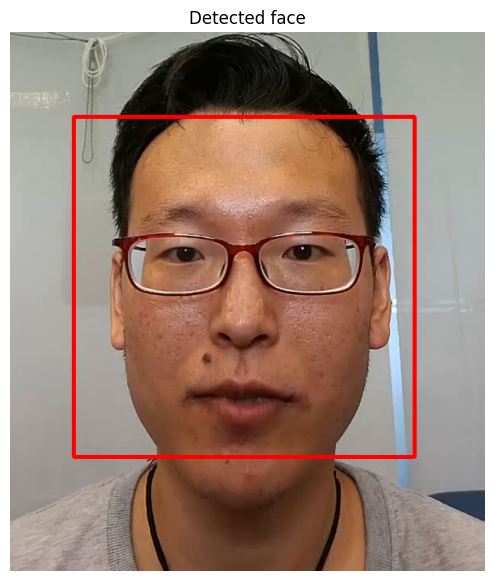

Detected face: [ 78 104 419 419]


Извлечение rPPG: 100%|██████████| 268/268 [00:00<00:00, 387.28it/s]

Успешно обработано сессий: 268


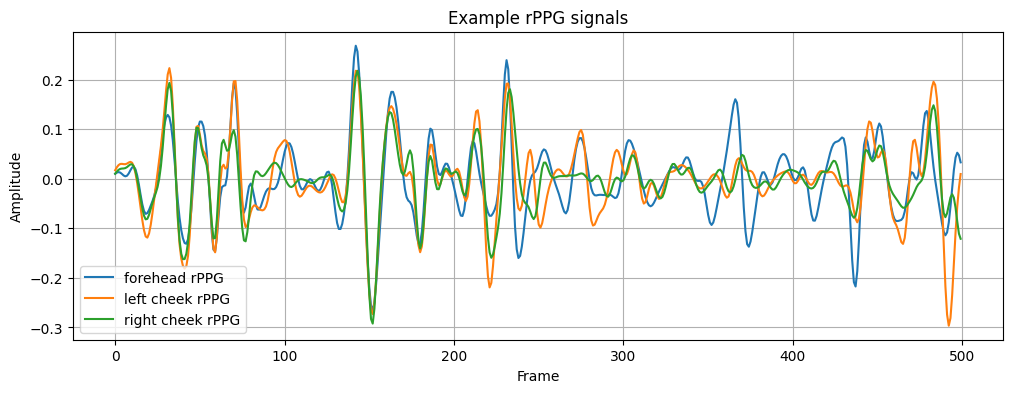

Формирование окон: 100%|██████████| 268/268 [00:47<00:00,  5.65it/s]

Dataset shape: (6442, 106)


,target_HR,session_id,person,session,source,start_sec,end_sec,forehead_rppg_mean,forehead_rppg_std,forehead_rppg_min,...,right_cheek_green_peak_ratio,right_cheek_R_mean,right_cheek_G_mean,right_cheek_B_mean,right_cheek_R_std,right_cheek_G_std,right_cheek_B_std,right_cheek_R_range,right_cheek_G_range,right_cheek_B_range
0,66.699997,p1-5_p1_v1_source2,p1,v1,source2,0,10,-0.000772,0.090003,-0.265258,...,0.376973,174.691940,116.214172,96.614700,6.256802,5.464105,5.754027,21.342331,18.555611,22.401062
1,66.900002,p1-5_p1_v1_source2,p1,v1,source2,1,11,0.001408,0.090576,-0.265258,...,0.395679,176.279434,117.502174,98.036797,4.446777,3.919252,4.060184,20.176437,17.492729,20.707092
2,67.000000,p1-5_p1_v1_source2,p1,v1,source2,2,12,-0.000433,0.086822,-0.265258,...,0.287085,177.449875,118.394394,99.031586,2.704453,2.581937,2.554202,12.577927,11.463142,13.815002
3,67.000000,p1-5_p1_v1_source2,p1,v1,source2,3,13,-0.002606,0.081926,-0.265258,...,0.298609,178.164307,118.872093,99.526840,1.571707,1.918437,1.873678,9.335907,8.283150,9.859848
4,67.000000,p1-5_p1_v1_source2,p1,v1,source2,4,14,0.001317,0.081468,-0.265258,...,0.299739,178.205933,118.776169,99.408745,1.376393,1.827123,1.833946,6.427109,6.434654,9.859848


Dataset shape after cleaning: (6442, 106)
Сохранено: hr_rppg_window_features_source2.csv


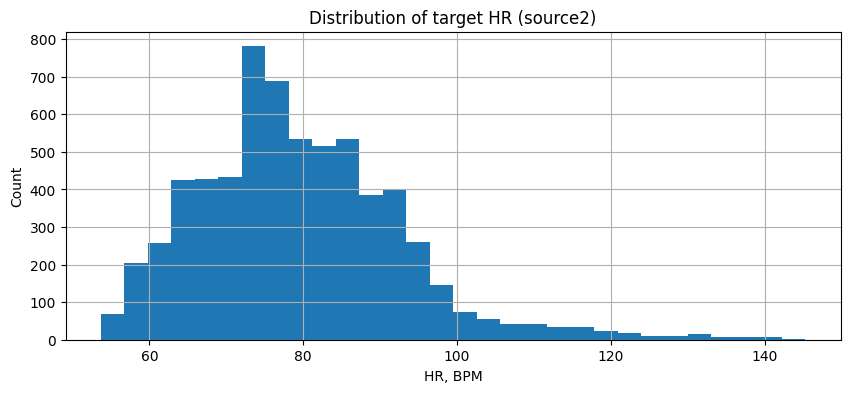

Peak BPM columns:
['forehead_rppg_peak_bpm', 'forehead_green_peak_bpm', 'left_cheek_rppg_peak_bpm', 'left_cheek_green_peak_bpm', 'right_cheek_rppg_peak_bpm', 'right_cheek_green_peak_bpm']


,peak_feature,MAE,RMSE
0,forehead_rppg_peak_bpm,19.752841,24.499888
1,right_cheek_rppg_peak_bpm,19.895281,24.543421
2,left_cheek_rppg_peak_bpm,20.062372,24.846509
3,right_cheek_green_peak_bpm,22.265896,27.678993
4,left_cheek_green_peak_bpm,22.578454,27.642432
5,forehead_green_peak_bpm,22.959034,28.362644


Train size: (5125, 99)
Test size: (1317, 99)
Train sessions: 213
Test sessions: 54
Сохранено: model_results_source2.csv
Best model: ExtraTrees
Best MAE: 8.078656406977062
Best RMSE: 10.775834538200796


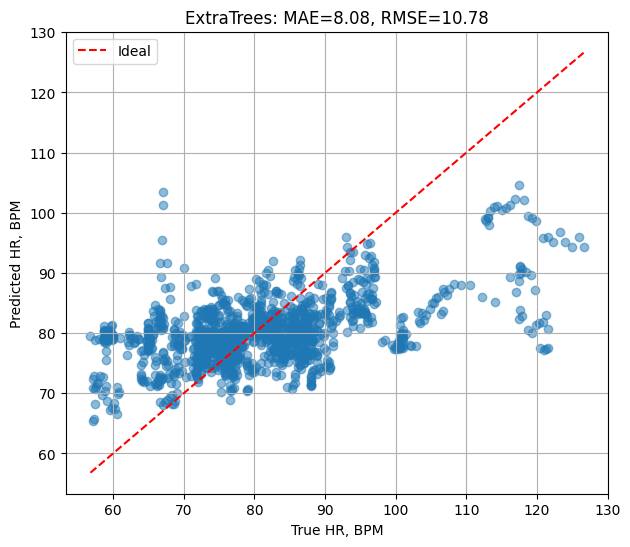

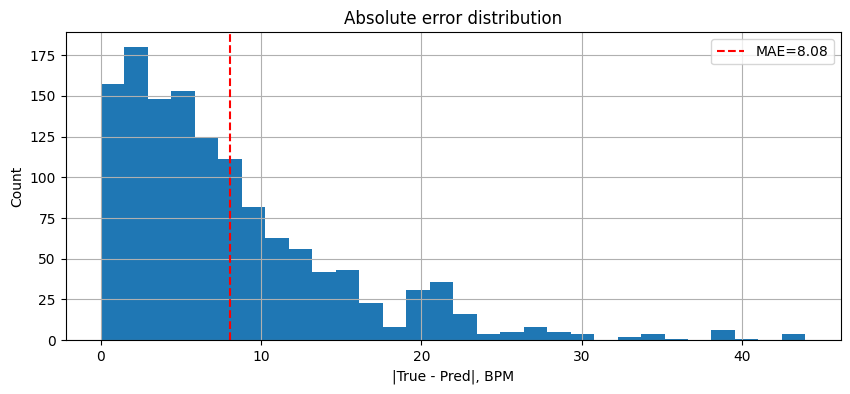

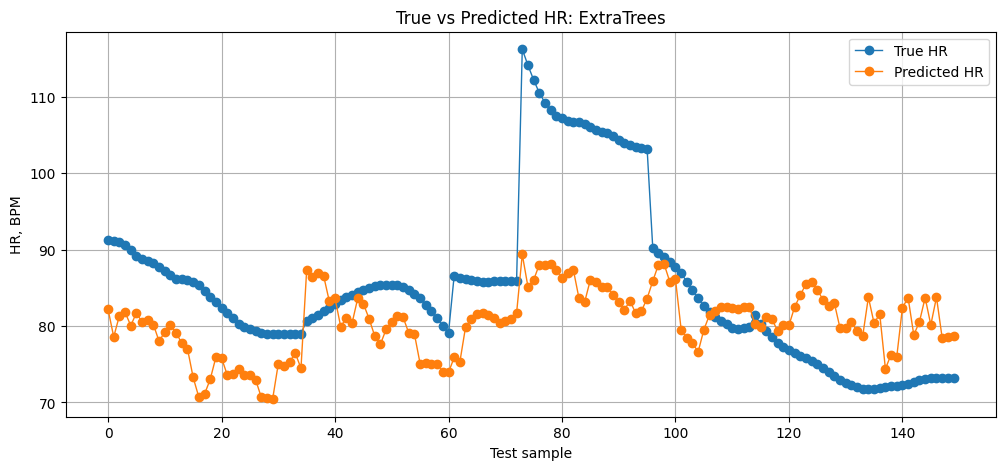

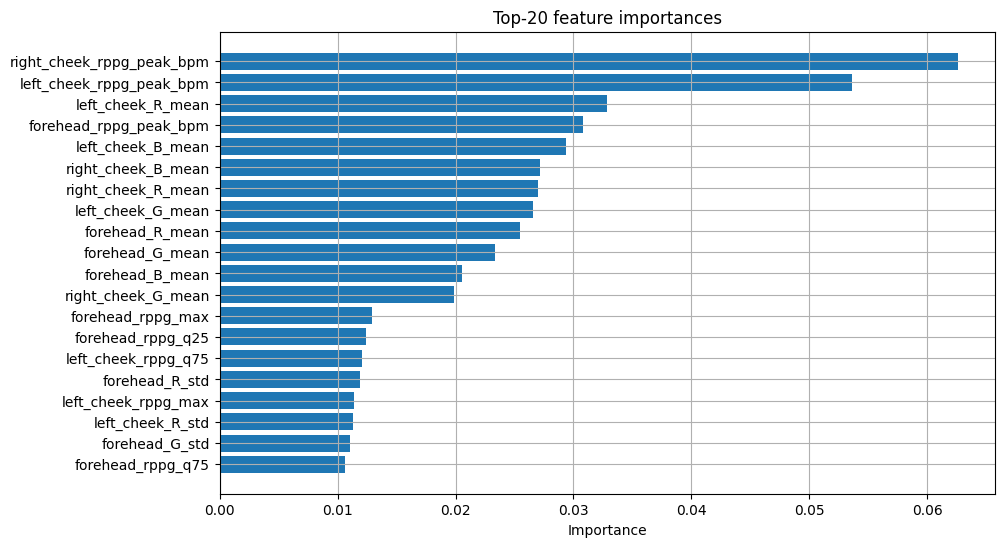

In [19]:
from pathlib import Path
import shutil
import warnings

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm import tqdm
from scipy.signal import butter, filtfilt, welch
from scipy.stats import skew, kurtosis

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, HistGradientBoostingRegressor

warnings.filterwarnings("ignore")


# ============================================================
# Основные настройки
# ============================================================

DATA_ROOT = Path("data-videos/VIPL/VIPL")

# Проверяем другой источник
SOURCE = "source2"

CACHE_DIR = Path("rppg_cache_source2")
CACHE_DIR.mkdir(exist_ok=True)

WINDOW_SEC = 10
STEP_SEC = 1

print("DATA_ROOT exists:", DATA_ROOT.exists())
print("SOURCE:", SOURCE)
print("CACHE_DIR:", CACHE_DIR)


# ============================================================
# Безопасная загрузка Haar Cascade
# ============================================================

safe_dir = Path(r"C:\temp")
safe_dir.mkdir(exist_ok=True)

src_cascade = Path(cv2.data.haarcascades) / "haarcascade_frontalface_default.xml"
safe_cascade = safe_dir / "haarcascade_frontalface_default.xml"

if not safe_cascade.exists():
    shutil.copy(src_cascade, safe_cascade)

face_cascade = cv2.CascadeClassifier(str(safe_cascade))

print("Cascade path:", safe_cascade)
print("Cascade loaded:", not face_cascade.empty())

if face_cascade.empty():
    raise RuntimeError("Не удалось загрузить Haar Cascade для детекции лица")


# ============================================================
# Детекция лица и выделение ROI
# ============================================================

def fallback_face(frame_bgr):
    """
    Запасной вариант, если детектор не нашёл лицо.
    Для VIPL лицо обычно расположено примерно по центру кадра.
    """
    h, w = frame_bgr.shape[:2]

    box_w = int(w * 0.55)
    box_h = int(h * 0.75)

    x = int((w - box_w) / 2)
    y = int(h * 0.08)

    return (x, y, box_w, box_h)


def detect_face(frame_bgr):
    """
    Возвращает координаты самого большого найденного лица: (x, y, w, h).
    Если лицо не найдено, возвращает fallback-область.
    """
    gray = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2GRAY)

    faces = face_cascade.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=5,
        minSize=(80, 80)
    )

    if len(faces) == 0:
        return fallback_face(frame_bgr)

    return max(faces, key=lambda f: f[2] * f[3])


def crop_mean_rgb(frame_bgr, x1, y1, x2, y2):
    """
    Вырезает область изображения и возвращает среднее значение RGB.
    """
    h, w = frame_bgr.shape[:2]

    x1 = max(0, min(w - 1, x1))
    x2 = max(0, min(w, x2))
    y1 = max(0, min(h - 1, y1))
    y2 = max(0, min(h, y2))

    roi = frame_bgr[y1:y2, x1:x2]

    if roi.size == 0:
        return np.zeros(3, dtype=np.float32)

    roi_rgb = cv2.cvtColor(roi, cv2.COLOR_BGR2RGB).astype(np.float32)

    return roi_rgb.mean(axis=(0, 1))


def get_rois_rgb(frame_bgr, face_box):
    """
    Выделяет три области интереса:
    1. forehead — лоб;
    2. left_cheek — левая щека;
    3. right_cheek — правая щека.

    Возвращает средние RGB-значения для каждой области.
    """
    x, y, w, h = face_box

    rois = {}

    # Лоб: центральная часть лица выше бровей
    fx1 = x + int(w * 0.30)
    fx2 = x + int(w * 0.70)
    fy1 = y + int(h * 0.16)
    fy2 = y + int(h * 0.30)

    # Левая щека
    lx1 = x + int(w * 0.18)
    lx2 = x + int(w * 0.38)
    ly1 = y + int(h * 0.48)
    ly2 = y + int(h * 0.70)

    # Правая щека
    rx1 = x + int(w * 0.62)
    rx2 = x + int(w * 0.82)
    ry1 = y + int(h * 0.48)
    ry2 = y + int(h * 0.70)

    rois["forehead"] = crop_mean_rgb(frame_bgr, fx1, fy1, fx2, fy2)
    rois["left_cheek"] = crop_mean_rgb(frame_bgr, lx1, ly1, lx2, ly2)
    rois["right_cheek"] = crop_mean_rgb(frame_bgr, rx1, ry1, rx2, ry2)

    return rois


# ============================================================
# Фильтрация и POS rPPG
# ============================================================

def bandpass_filter(signal, fs, low=0.7, high=3.0, order=3):
    """
    Полосовой фильтр для диапазона пульса.
    0.7–3.0 Гц соответствует примерно 42–180 BPM.
    """
    signal = np.asarray(signal, dtype=np.float32)

    if len(signal) < fs * 3:
        return signal

    nyq = 0.5 * fs
    low_norm = low / nyq
    high_norm = high / nyq

    b, a = butter(order, [low_norm, high_norm], btype="band")

    try:
        filtered = filtfilt(b, a, signal)
        return filtered.astype(np.float32)
    except Exception:
        return signal


def pos_algorithm(rgb_trace, fs, win_sec=1.6):
    """
    POS-алгоритм для извлечения rPPG-сигнала из RGB-трассы.
    """
    rgb_trace = np.asarray(rgb_trace, dtype=np.float32)

    n = rgb_trace.shape[0]
    win = int(win_sec * fs)

    if n < win + 2:
        return np.zeros(n, dtype=np.float32)

    h_signal = np.zeros(n, dtype=np.float32)

    for i in range(win, n):
        segment = rgb_trace[i - win:i].T

        mean = np.mean(segment, axis=1, keepdims=True)
        mean[mean == 0] = 1e-6

        normalized = segment / mean

        s1 = normalized[1] - normalized[2]
        s2 = -2 * normalized[0] + normalized[1] + normalized[2]

        alpha = np.std(s1) / (np.std(s2) + 1e-6)

        pos = s1 + alpha * s2
        pos = pos - np.mean(pos)

        h_signal[i - win:i] += pos * np.hanning(win)

    h_signal = bandpass_filter(h_signal, fs)

    return h_signal.astype(np.float32)


# ============================================================
# Извлечение rPPG из одного видео
# ============================================================

def extract_rppg_from_video(video_path: Path, cache_path: Path):
    """
    Читает видео, выделяет лицо, извлекает RGB-трассы и rPPG-сигналы.
    Результат кэшируется в .npz.
    """
    if cache_path.exists():
        data = np.load(cache_path)
        return {k: data[k] for k in data.files}

    cap = cv2.VideoCapture(str(video_path))

    if not cap.isOpened():
        return None

    fps = cap.get(cv2.CAP_PROP_FPS)

    if fps <= 0:
        fps = 25.0

    traces = {
        "forehead_rgb": [],
        "left_cheek_rgb": [],
        "right_cheek_rgb": []
    }

    last_face = None
    frame_idx = 0

    while True:
        ret, frame = cap.read()

        if not ret:
            break

        # Лицо ищем не на каждом кадре, чтобы ускорить обработку
        if frame_idx % 10 == 0:
            last_face = detect_face(frame)

        if last_face is None:
            last_face = fallback_face(frame)

        rois = get_rois_rgb(frame, last_face)

        traces["forehead_rgb"].append(rois["forehead"])
        traces["left_cheek_rgb"].append(rois["left_cheek"])
        traces["right_cheek_rgb"].append(rois["right_cheek"])

        frame_idx += 1

    cap.release()

    if frame_idx == 0:
        return None

    result = {
        "fps": np.array([fps], dtype=np.float32)
    }

    for roi_name in ["forehead", "left_cheek", "right_cheek"]:
        rgb = np.array(traces[f"{roi_name}_rgb"], dtype=np.float32)

        result[f"{roi_name}_rgb"] = rgb

        rppg = pos_algorithm(rgb, fps)
        result[f"{roi_name}_rppg"] = rppg.astype(np.float32)

        green = rgb[:, 1]
        green_filtered = bandpass_filter(green, fps)
        result[f"{roi_name}_green"] = green_filtered.astype(np.float32)

    np.savez_compressed(cache_path, **result)

    return result


# ============================================================
# Сбор путей к видео
# ============================================================

def collect_video_paths(data_root: Path, source: str):
    """
    Собирает все видео выбранного source.
    """
    paths = []

    for group_dir in sorted(data_root.iterdir()):
        if not group_dir.is_dir():
            continue

        for person_dir in sorted(group_dir.iterdir()):
            if not person_dir.is_dir():
                continue

            for session_dir in sorted(person_dir.iterdir()):
                if not session_dir.is_dir():
                    continue

                src_dir = session_dir / source

                if not src_dir.is_dir():
                    continue

                video_path = src_dir / "video.avi"
                hr_path = src_dir / "gt_HR.csv"
                spo2_path = src_dir / "gt_SpO2.csv"
                time_path = src_dir / "time.txt"

                if video_path.exists() and hr_path.exists():
                    session_id = f"{group_dir.name}_{person_dir.name}_{session_dir.name}_{source}"

                    paths.append({
                        "group": group_dir.name,
                        "person": person_dir.name,
                        "session": session_dir.name,
                        "source": source,
                        "session_id": session_id,
                        "src_dir": src_dir,
                        "video_path": video_path,
                        "hr_path": hr_path,
                        "spo2_path": spo2_path if spo2_path.exists() else None,
                        "time_path": time_path if time_path.exists() else None
                    })

    return paths


video_paths = collect_video_paths(DATA_ROOT, SOURCE)

print("Найдено видео:", len(video_paths))

if len(video_paths) > 0:
    print(video_paths[0])


# ============================================================
# Проверка детекции лица на первом видео
# ============================================================

if len(video_paths) > 0:
    test_video = video_paths[0]["video_path"]

    cap = cv2.VideoCapture(str(test_video))
    ret, frame = cap.read()
    cap.release()

    if ret:
        face = detect_face(frame)

        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frame_vis = frame_rgb.copy()

        x, y, w, h = face
        cv2.rectangle(frame_vis, (x, y), (x + w, y + h), (255, 0, 0), 3)

        plt.figure(figsize=(7, 7))
        plt.imshow(frame_vis)
        plt.title("Detected face")
        plt.axis("off")
        plt.show()

        print("Detected face:", face)


# ============================================================
# Сбор сессий с rPPG
# ============================================================

def collect_sessions(video_paths, cache_dir: Path, max_sessions=None):
    """
    Обрабатывает видео и собирает rPPG-данные вместе с HR-разметкой.
    """
    sessions = []

    selected_paths = video_paths if max_sessions is None else video_paths[:max_sessions]

    for item in tqdm(selected_paths, desc="Извлечение rPPG"):
        cache_file = cache_dir / f"{item['session_id']}.npz"

        rppg_data = extract_rppg_from_video(item["video_path"], cache_file)

        if rppg_data is None:
            continue

        try:
            hr_df = pd.read_csv(item["hr_path"])
            hr = pd.to_numeric(hr_df["HR"], errors="coerce").dropna().values.astype(np.float32)
        except Exception:
            continue

        if len(hr) == 0:
            continue

        sessions.append({
            **item,
            "rppg_data": rppg_data,
            "hr": hr,
            "fps": float(rppg_data["fps"][0])
        })

    return sessions

all_sessions = collect_sessions(video_paths, CACHE_DIR, max_sessions=None)

print("Успешно обработано сессий:", len(all_sessions))


# ============================================================
# Визуальная проверка rPPG-сигнала
# ============================================================

if len(all_sessions) > 0:
    s = all_sessions[0]
    fps = s["fps"]

    n = int(fps * 20)

    plt.figure(figsize=(12, 4))
    plt.plot(s["rppg_data"]["forehead_rppg"][:n], label="forehead rPPG")
    plt.plot(s["rppg_data"]["left_cheek_rppg"][:n], label="left cheek rPPG")
    plt.plot(s["rppg_data"]["right_cheek_rppg"][:n], label="right cheek rPPG")
    plt.title("Example rPPG signals")
    plt.xlabel("Frame")
    plt.ylabel("Amplitude")
    plt.grid(True)
    plt.legend()
    plt.show()


# ============================================================
# Признаки из сигнала
# ============================================================

def dominant_hr_from_signal(signal, fs):
    """
    Оценивает доминирующую частоту сигнала через спектр.
    Возвращает:
    - peak_bpm;
    - peak_ratio.
    """
    signal = np.asarray(signal, dtype=np.float32)

    if len(signal) < fs * 3:
        return 0.0, 0.0

    signal = signal - np.mean(signal)

    if np.std(signal) < 1e-6:
        return 0.0, 0.0

    nperseg = min(len(signal), int(fs * 8))

    freqs, power = welch(signal, fs=fs, nperseg=nperseg)

    mask = (freqs >= 0.7) & (freqs <= 3.0)

    if mask.sum() == 0:
        return 0.0, 0.0

    freqs_band = freqs[mask]
    power_band = power[mask]

    peak_idx = np.argmax(power_band)

    peak_freq = freqs_band[peak_idx]
    peak_bpm = peak_freq * 60.0

    peak_power = power_band[peak_idx]
    total_power = np.sum(power_band) + 1e-6

    peak_ratio = peak_power / total_power

    return float(peak_bpm), float(peak_ratio)


def signal_features(signal, fs, prefix):
    """
    Считает статистические и частотные признаки для одного сигнала.
    """
    signal = np.asarray(signal, dtype=np.float32)

    if len(signal) == 0:
        return {}

    features = {}

    features[f"{prefix}_mean"] = float(np.mean(signal))
    features[f"{prefix}_std"] = float(np.std(signal))
    features[f"{prefix}_min"] = float(np.min(signal))
    features[f"{prefix}_max"] = float(np.max(signal))
    features[f"{prefix}_range"] = float(np.max(signal) - np.min(signal))
    features[f"{prefix}_median"] = float(np.median(signal))
    features[f"{prefix}_q25"] = float(np.percentile(signal, 25))
    features[f"{prefix}_q75"] = float(np.percentile(signal, 75))
    features[f"{prefix}_skew"] = float(skew(signal))
    features[f"{prefix}_kurtosis"] = float(kurtosis(signal))

    peak_bpm, peak_ratio = dominant_hr_from_signal(signal, fs)

    features[f"{prefix}_peak_bpm"] = peak_bpm
    features[f"{prefix}_peak_ratio"] = peak_ratio

    return features


def build_window_dataset(sessions, window_sec=10, step_sec=1):
    """
    Делит каждое видео на окна и формирует табличный датасет:
    одно окно сигнала → признаки → средний HR за это окно.
    """
    rows = []

    for s in tqdm(sessions, desc="Формирование окон"):
        fps = s["fps"]
        hr = s["hr"]
        rppg_data = s["rppg_data"]

        n_frames = len(rppg_data["forehead_rppg"])
        video_duration_sec = int(n_frames / fps)
        hr_duration_sec = len(hr)

        duration_sec = min(video_duration_sec, hr_duration_sec)

        if duration_sec < window_sec:
            continue

        for start_sec in range(0, duration_sec - window_sec + 1, step_sec):
            end_sec = start_sec + window_sec

            start_frame = int(start_sec * fps)
            end_frame = int(end_sec * fps)

            row = {
                "target_HR": float(np.mean(hr[start_sec:end_sec])),
                "session_id": s["session_id"],
                "person": s["person"],
                "session": s["session"],
                "source": s["source"],
                "start_sec": start_sec,
                "end_sec": end_sec
            }

            for roi in ["forehead", "left_cheek", "right_cheek"]:
                rppg_signal = rppg_data[f"{roi}_rppg"][start_frame:end_frame]
                green_signal = rppg_data[f"{roi}_green"][start_frame:end_frame]
                rgb_signal = rppg_data[f"{roi}_rgb"][start_frame:end_frame]

                row.update(signal_features(rppg_signal, fps, f"{roi}_rppg"))
                row.update(signal_features(green_signal, fps, f"{roi}_green"))

                if len(rgb_signal) > 0:
                    row[f"{roi}_R_mean"] = float(np.mean(rgb_signal[:, 0]))
                    row[f"{roi}_G_mean"] = float(np.mean(rgb_signal[:, 1]))
                    row[f"{roi}_B_mean"] = float(np.mean(rgb_signal[:, 2]))

                    row[f"{roi}_R_std"] = float(np.std(rgb_signal[:, 0]))
                    row[f"{roi}_G_std"] = float(np.std(rgb_signal[:, 1]))
                    row[f"{roi}_B_std"] = float(np.std(rgb_signal[:, 2]))

                    row[f"{roi}_R_range"] = float(np.max(rgb_signal[:, 0]) - np.min(rgb_signal[:, 0]))
                    row[f"{roi}_G_range"] = float(np.max(rgb_signal[:, 1]) - np.min(rgb_signal[:, 1]))
                    row[f"{roi}_B_range"] = float(np.max(rgb_signal[:, 2]) - np.min(rgb_signal[:, 2]))

            rows.append(row)

    return pd.DataFrame(rows)


dataset_df = build_window_dataset(
    all_sessions,
    window_sec=WINDOW_SEC,
    step_sec=STEP_SEC
)

print("Dataset shape:", dataset_df.shape)
display(dataset_df.head())


dataset_df = dataset_df.replace([np.inf, -np.inf], np.nan)
dataset_df = dataset_df.dropna().reset_index(drop=True)

print("Dataset shape after cleaning:", dataset_df.shape)

dataset_file = f"hr_rppg_window_features_{SOURCE}.csv"
dataset_df.to_csv(dataset_file, index=False)

print("Сохранено:", dataset_file)

plt.figure(figsize=(10, 4))
plt.hist(dataset_df["target_HR"], bins=30)
plt.title(f"Distribution of target HR ({SOURCE})")
plt.xlabel("HR, BPM")
plt.ylabel("Count")
plt.grid(True)
plt.show()


# ============================================================
# Проверка качества peak_bpm как самостоятельного признака
# ============================================================

peak_cols = [col for col in dataset_df.columns if "peak_bpm" in col]

print("Peak BPM columns:")
print(peak_cols)

peak_results = []

for col in peak_cols:
    mae_peak = mean_absolute_error(dataset_df["target_HR"], dataset_df[col])
    rmse_peak = np.sqrt(mean_squared_error(dataset_df["target_HR"], dataset_df[col]))

    peak_results.append({
        "peak_feature": col,
        "MAE": mae_peak,
        "RMSE": rmse_peak
    })

peak_results_df = pd.DataFrame(peak_results).sort_values("MAE").reset_index(drop=True)

display(peak_results_df)


# ============================================================
# Обучение моделей
# ============================================================

meta_columns = [
    "target_HR",
    "session_id",
    "person",
    "session",
    "source",
    "start_sec",
    "end_sec"
]

feature_columns = [col for col in dataset_df.columns if col not in meta_columns]

X = dataset_df[feature_columns]
y = dataset_df["target_HR"]
groups = dataset_df["session_id"]

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

train_idx, test_idx = next(splitter.split(X, y, groups=groups))

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)
print("Train sessions:", dataset_df.iloc[train_idx]["session_id"].nunique())
print("Test sessions:", dataset_df.iloc[test_idx]["session_id"].nunique())


models = {
    "Baseline mean": None,

    "RandomForest": RandomForestRegressor(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ),

    "ExtraTrees": ExtraTreesRegressor(
        n_estimators=500,
        max_depth=None,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ),

    "HistGradientBoosting": HistGradientBoostingRegressor(
        max_iter=400,
        learning_rate=0.04,
        max_leaf_nodes=31,
        l2_regularization=0.1,
        random_state=42
    )
}


results = []
predictions = {}

for name, model in models.items():
    if model is None:
        y_pred = np.full_like(y_test.values, fill_value=y_train.mean(), dtype=np.float32)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    within_5 = np.mean(np.abs(y_test.values - y_pred) < 5) * 100
    within_10 = np.mean(np.abs(y_test.values - y_pred) < 10) * 100

    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "< 5 BPM, %": within_5,
        "< 10 BPM, %": within_10
    })

    predictions[name] = y_pred


results_df = pd.DataFrame(results).sort_values("MAE").reset_index(drop=True)

results_df

results_file = f"model_results_{SOURCE}.csv"
results_df.to_csv(results_file, index=False)

print("Сохранено:", results_file)


# ============================================================
# Графики лучшей модели
# ============================================================

best_model_name = results_df.iloc[0]["Model"]
best_pred = predictions[best_model_name]

best_mae = mean_absolute_error(y_test, best_pred)
best_rmse = np.sqrt(mean_squared_error(y_test, best_pred))

print("Best model:", best_model_name)
print("Best MAE:", best_mae)
print("Best RMSE:", best_rmse)


plt.figure(figsize=(7, 6))
plt.scatter(y_test, best_pred, alpha=0.5)

min_v = min(y_test.min(), best_pred.min())
max_v = max(y_test.max(), best_pred.max())

plt.plot([min_v, max_v], [min_v, max_v], "r--", label="Ideal")

plt.title(f"{best_model_name}: MAE={best_mae:.2f}, RMSE={best_rmse:.2f}")
plt.xlabel("True HR, BPM")
plt.ylabel("Predicted HR, BPM")
plt.grid(True)
plt.legend()
plt.show()


errors = np.abs(y_test.values - best_pred)

plt.figure(figsize=(10, 4))
plt.hist(errors, bins=30)
plt.axvline(best_mae, color="red", linestyle="--", label=f"MAE={best_mae:.2f}")
plt.title("Absolute error distribution")
plt.xlabel("|True - Pred|, BPM")
plt.ylabel("Count")
plt.grid(True)
plt.legend()
plt.show()


plt.figure(figsize=(12, 5))
plt.plot(y_test.values[:150], label="True HR", marker="o", linewidth=1)
plt.plot(best_pred[:150], label="Predicted HR", marker="o", linewidth=1)

plt.title(f"True vs Predicted HR: {best_model_name}")
plt.xlabel("Test sample")
plt.ylabel("HR, BPM")
plt.grid(True)
plt.legend()
plt.show()


# ============================================================
# Важность признаков
# ============================================================

if best_model_name in ["RandomForest", "ExtraTrees"]:
    best_model = models[best_model_name]

    importances = best_model.feature_importances_

    importance_df = pd.DataFrame({
        "feature": feature_columns,
        "importance": importances
    }).sort_values("importance", ascending=False)

    importance_df.head(20)

    plt.figure(figsize=(10, 6))
    plt.barh(
        importance_df.head(20)["feature"][::-1],
        importance_df.head(20)["importance"][::-1]
    )
    plt.title("Top-20 feature importances")
    plt.xlabel("Importance")
    plt.grid(True)
    plt.show()

# Улучшение

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupShuffleSplit, GroupKFold, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.ensemble import (
    ExtraTreesRegressor,
    RandomForestRegressor,
    HistGradientBoostingRegressor,
    GradientBoostingRegressor,
    VotingRegressor,
    StackingRegressor
)

from sklearn.linear_model import Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

import warnings
warnings.filterwarnings("ignore")


# ============================================================
# Загрузка датасета
# ============================================================

dataset_df = pd.read_csv("hr_rppg_window_features_source2.csv")

print("Dataset shape:", dataset_df.shape)
dataset_df.head()

dataset_df = dataset_df.replace([np.inf, -np.inf], np.nan)
dataset_df = dataset_df.dropna().reset_index(drop=True)

print("Dataset shape after cleaning:", dataset_df.shape)


# ============================================================
# Дополнительная генерация признаков
# ============================================================

def add_engineered_features(df):
    df = df.copy()

    peak_bpm_cols = [col for col in df.columns if "peak_bpm" in col]
    peak_ratio_cols = [col for col in df.columns if "peak_ratio" in col]

    if len(peak_bpm_cols) > 0:
        df["peak_bpm_mean"] = df[peak_bpm_cols].mean(axis=1)
        df["peak_bpm_median"] = df[peak_bpm_cols].median(axis=1)
        df["peak_bpm_std"] = df[peak_bpm_cols].std(axis=1)
        df["peak_bpm_min"] = df[peak_bpm_cols].min(axis=1)
        df["peak_bpm_max"] = df[peak_bpm_cols].max(axis=1)
        df["peak_bpm_range"] = df["peak_bpm_max"] - df["peak_bpm_min"]

    if len(peak_ratio_cols) > 0:
        df["peak_ratio_mean"] = df[peak_ratio_cols].mean(axis=1)
        df["peak_ratio_median"] = df[peak_ratio_cols].median(axis=1)
        df["peak_ratio_std"] = df[peak_ratio_cols].std(axis=1)
        df["peak_ratio_max"] = df[peak_ratio_cols].max(axis=1)

    # Взвешенный peak_bpm: чем выше peak_ratio, тем больше доверяем признаку
    if len(peak_bpm_cols) > 0 and len(peak_ratio_cols) > 0:
        common_pairs = []

        for bpm_col in peak_bpm_cols:
            ratio_col = bpm_col.replace("peak_bpm", "peak_ratio")
            if ratio_col in df.columns:
                common_pairs.append((bpm_col, ratio_col))

        if len(common_pairs) > 0:
            weighted_sum = np.zeros(len(df))
            weight_sum = np.zeros(len(df))

            for bpm_col, ratio_col in common_pairs:
                weighted_sum += df[bpm_col].values * df[ratio_col].values
                weight_sum += df[ratio_col].values

            df["weighted_peak_bpm"] = weighted_sum / (weight_sum + 1e-6)

    # Разница между rPPG peak и green peak для каждой ROI
    for roi in ["forehead", "left_cheek", "right_cheek"]:
        rppg_col = f"{roi}_rppg_peak_bpm"
        green_col = f"{roi}_green_peak_bpm"

        if rppg_col in df.columns and green_col in df.columns:
            df[f"{roi}_peak_diff"] = df[rppg_col] - df[green_col]
            df[f"{roi}_peak_abs_diff"] = np.abs(df[rppg_col] - df[green_col])

    # RGB ratios по ROI
    for roi in ["forehead", "left_cheek", "right_cheek"]:
        r_col = f"{roi}_R_mean"
        g_col = f"{roi}_G_mean"
        b_col = f"{roi}_B_mean"

        if r_col in df.columns and g_col in df.columns and b_col in df.columns:
            df[f"{roi}_R_div_G"] = df[r_col] / (df[g_col] + 1e-6)
            df[f"{roi}_B_div_G"] = df[b_col] / (df[g_col] + 1e-6)
            df[f"{roi}_R_minus_G"] = df[r_col] - df[g_col]
            df[f"{roi}_B_minus_G"] = df[b_col] - df[g_col]

    # Усреднение RGB по трём ROI
    for channel in ["R", "G", "B"]:
        cols = [
            f"forehead_{channel}_mean",
            f"left_cheek_{channel}_mean",
            f"right_cheek_{channel}_mean"
        ]

        existing_cols = [col for col in cols if col in df.columns]

        if len(existing_cols) > 0:
            df[f"{channel}_mean_all_rois"] = df[existing_cols].mean(axis=1)
            df[f"{channel}_std_all_rois"] = df[existing_cols].std(axis=1)

    return df


dataset_df = add_engineered_features(dataset_df)

dataset_df = dataset_df.replace([np.inf, -np.inf], np.nan)
dataset_df = dataset_df.dropna().reset_index(drop=True)

print("Dataset shape after feature engineering:", dataset_df.shape)
display(dataset_df.head())


# ============================================================
# Подготовка X, y и group split
# ============================================================

meta_columns = [
    "target_HR",
    "session_id",
    "person",
    "session",
    "source",
    "start_sec",
    "end_sec"
]

feature_columns = [col for col in dataset_df.columns if col not in meta_columns]

X = dataset_df[feature_columns]
y = dataset_df["target_HR"]
groups = dataset_df["session_id"]

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

train_idx, test_idx = next(splitter.split(X, y, groups=groups))

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

groups_train = groups.iloc[train_idx]

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)
print("Train sessions:", groups_train.nunique())
print("Test sessions:", groups.iloc[test_idx].nunique())


# ============================================================
# Baseline
# ============================================================

baseline_pred = np.full_like(y_test.values, fill_value=y_train.mean(), dtype=np.float32)

baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))

print("Baseline MAE:", baseline_mae)
print("Baseline RMSE:", baseline_rmse)


# ============================================================
# Подбор гиперпараметров для ExtraTrees
# ============================================================

extra_trees_base = ExtraTreesRegressor(
    random_state=42,
    n_jobs=-1
)

param_dist = {
    "n_estimators": [300, 500, 700, 900],
    "max_depth": [None, 8, 12, 16, 20, 30],
    "min_samples_split": [2, 4, 6, 10],
    "min_samples_leaf": [1, 2, 3, 4, 5],
    "max_features": ["sqrt", "log2", 0.5, 0.7, 1.0]
}

group_kfold = GroupKFold(n_splits=5)

search = RandomizedSearchCV(
    estimator=extra_trees_base,
    param_distributions=param_dist,
    n_iter=25,
    scoring="neg_mean_absolute_error",
    cv=group_kfold,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train, y_train, groups=groups_train)

print("Best ExtraTrees params:")
print(search.best_params_)
print("Best CV MAE:", -search.best_score_)

best_extra_trees = search.best_estimator_


# ============================================================
# обучение нескольких моделей
# ============================================================

models = {
    "Baseline mean": None,

    "ExtraTrees tuned": best_extra_trees,

    "ExtraTrees default": ExtraTreesRegressor(
        n_estimators=500,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ),

    "RandomForest": RandomForestRegressor(
        n_estimators=500,
        max_depth=None,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ),

    "HistGradientBoosting": HistGradientBoostingRegressor(
        max_iter=500,
        learning_rate=0.03,
        max_leaf_nodes=31,
        l2_regularization=0.1,
        random_state=42
    ),

    "GradientBoosting": GradientBoostingRegressor(
        n_estimators=400,
        learning_rate=0.03,
        max_depth=3,
        random_state=42
    ),

    "KNN scaled": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", KNeighborsRegressor(
            n_neighbors=9,
            weights="distance"
        ))
    ]),

    "SVR scaled": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", SVR(
            C=10,
            epsilon=2,
            gamma="scale"
        ))
    ]),

    "Ridge scaled": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=10.0))
    ])
}


results = []
predictions = {}
trained_models = {}

for name, model in models.items():
    print("Training:", name)

    if model is None:
        y_pred = np.full_like(y_test.values, fill_value=y_train.mean(), dtype=np.float32)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        trained_models[name] = model

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    within_5 = np.mean(np.abs(y_test.values - y_pred) < 5) * 100
    within_10 = np.mean(np.abs(y_test.values - y_pred) < 10) * 100

    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "< 5 BPM, %": within_5,
        "< 10 BPM, %": within_10
    })

    predictions[name] = y_pred


results_df = pd.DataFrame(results).sort_values("MAE").reset_index(drop=True)

results_df


# ============================================================
# Ансамбль лучших моделей
# ============================================================

# Берём несколько моделей, которые обычно хорошо работают на табличных признаках
voting_model = VotingRegressor(
    estimators=[
        ("extra_tuned", best_extra_trees),
        ("extra_default", ExtraTreesRegressor(
            n_estimators=500,
            min_samples_leaf=2,
            random_state=42,
            n_jobs=-1
        )),
        ("hgb", HistGradientBoostingRegressor(
            max_iter=500,
            learning_rate=0.03,
            max_leaf_nodes=31,
            l2_regularization=0.1,
            random_state=42
        )),
        ("rf", RandomForestRegressor(
            n_estimators=500,
            min_samples_leaf=2,
            random_state=42,
            n_jobs=-1
        ))
    ],
    weights=[3, 2, 1, 1],
    n_jobs=-1
)

voting_model.fit(X_train, y_train)

voting_pred = voting_model.predict(X_test)

voting_mae = mean_absolute_error(y_test, voting_pred)
voting_rmse = np.sqrt(mean_squared_error(y_test, voting_pred))

voting_within_5 = np.mean(np.abs(y_test.values - voting_pred) < 5) * 100
voting_within_10 = np.mean(np.abs(y_test.values - voting_pred) < 10) * 100

ensemble_row = pd.DataFrame([{
    "Model": "Voting ensemble",
    "MAE": voting_mae,
    "RMSE": voting_rmse,
    "< 5 BPM, %": voting_within_5,
    "< 10 BPM, %": voting_within_10
}])

results_df = pd.concat([results_df, ensemble_row], ignore_index=True)
results_df = results_df.sort_values("MAE").reset_index(drop=True)

predictions["Voting ensemble"] = voting_pred
trained_models["Voting ensemble"] = voting_model

display(results_df)


# ============================================================
# Сохранение результатов
# ============================================================

results_df.to_csv("improved_results_source2_engineered.csv", index=False)

print("Сохранено: improved_results_source2_engineered.csv")


# ============================================================
# Графики лучшей модели
# ============================================================

best_model_name = results_df.iloc[0]["Model"]
best_pred = predictions[best_model_name]

best_mae = mean_absolute_error(y_test, best_pred)
best_rmse = np.sqrt(mean_squared_error(y_test, best_pred))

print("Best model:", best_model_name)
print("Best MAE:", best_mae)
print("Best RMSE:", best_rmse)

plt.figure(figsize=(7, 6))
plt.scatter(y_test, best_pred, alpha=0.5)

min_v = min(y_test.min(), best_pred.min())
max_v = max(y_test.max(), best_pred.max())

plt.plot([min_v, max_v], [min_v, max_v], "r--", label="Ideal")

plt.title(f"{best_model_name}: MAE={best_mae:.2f}, RMSE={best_rmse:.2f}")
plt.xlabel("True HR, BPM")
plt.ylabel("Predicted HR, BPM")
plt.grid(True)
plt.legend()
plt.show()


errors = np.abs(y_test.values - best_pred)

plt.figure(figsize=(10, 4))
plt.hist(errors, bins=30)
plt.axvline(best_mae, color="red", linestyle="--", label=f"MAE={best_mae:.2f}")
plt.title("Absolute error distribution")
plt.xlabel("|True - Pred|, BPM")
plt.ylabel("Count")
plt.grid(True)
plt.legend()
plt.show()


plt.figure(figsize=(12, 5))
plt.plot(y_test.values[:150], label="True HR", marker="o", linewidth=1)
plt.plot(best_pred[:150], label="Predicted HR", marker="o", linewidth=1)

plt.title(f"True vs Predicted HR: {best_model_name}")
plt.xlabel("Test sample")
plt.ylabel("HR, BPM")
plt.grid(True)
plt.legend()
plt.show()


# ============================================================
# Важность признаков, если лучшая модель деревья
# ============================================================

model_for_importance = None

if best_model_name in trained_models:
    candidate_model = trained_models[best_model_name]

    if hasattr(candidate_model, "feature_importances_"):
        model_for_importance = candidate_model

if model_for_importance is None:
    if "ExtraTrees tuned" in trained_models:
        model_for_importance = trained_models["ExtraTrees tuned"]

if model_for_importance is not None and hasattr(model_for_importance, "feature_importances_"):
    importance_df = pd.DataFrame({
        "feature": feature_columns,
        "importance": model_for_importance.feature_importances_
    }).sort_values("importance", ascending=False)

    importance_df.head(25)

    plt.figure(figsize=(10, 7))
    plt.barh(
        importance_df.head(25)["feature"][::-1],
        importance_df.head(25)["importance"][::-1]
    )
    plt.title("Top-25 feature importances")
    plt.xlabel("Importance")
    plt.grid(True)
    plt.show()


# ============================================================
# Сравнение с предыдущим результатом
# ============================================================

print("Previous best result was approximately:")
print("ExtraTrees MAE ≈ 8.08, RMSE ≈ 10.78")

print("\nCurrent best result:")
print(f"{best_model_name}: MAE = {best_mae:.3f}, RMSE = {best_rmse:.3f}")

print("\nImprovement over previous MAE:")
print(8.078656 - best_mae)

Dataset shape: (6442, 106)
Dataset shape after cleaning: (6442, 106)
Dataset shape after feature engineering: (6442, 141)


,target_HR,session_id,person,session,source,start_sec,end_sec,forehead_rppg_mean,forehead_rppg_std,forehead_rppg_min,...,right_cheek_R_div_G,right_cheek_B_div_G,right_cheek_R_minus_G,right_cheek_B_minus_G,R_mean_all_rois,R_std_all_rois,G_mean_all_rois,G_std_all_rois,B_mean_all_rois,B_std_all_rois
0,66.699997,p1-5_p1_v1_source2,p1,v1,source2,0,10,-0.000772,0.090003,-0.265258,...,1.503190,0.831350,58.477768,-19.599472,188.011505,17.544532,128.252914,17.419686,105.059957,12.627140
1,66.900002,p1-5_p1_v1_source2,p1,v1,source2,1,11,0.001408,0.090576,-0.265258,...,1.500223,0.834340,58.777260,-19.465378,189.553396,17.462608,129.425046,17.219618,106.391703,12.559655
2,67.000000,p1-5_p1_v1_source2,p1,v1,source2,2,12,-0.000433,0.086822,-0.265258,...,1.498803,0.836455,59.055481,-19.362808,190.879669,17.567976,130.415377,17.215292,107.470586,12.560693
3,67.000000,p1-5_p1_v1_source2,p1,v1,source2,3,13,-0.002606,0.081926,-0.265258,...,1.498790,0.837260,59.292213,-19.345253,191.535904,17.494767,130.814690,17.126225,107.902395,12.496234
4,67.000000,p1-5_p1_v1_source2,p1,v1,source2,4,14,0.001317,0.081468,-0.265258,...,1.500351,0.836942,59.429764,-19.367424,191.692663,17.703306,130.842072,17.327535,107.846425,12.633051


Train size: (5125, 134)
Test size: (1317, 134)
Train sessions: 213
Test sessions: 54
Baseline MAE: 9.332490757367967
Baseline RMSE: 12.633919864786913
Fitting 5 folds for each of 25 candidates, totalling 125 fits
